<div style="border-left: 4px solid #FFB347; border-radius: 6px; background-color: white; box-shadow: 0 3px 10px rgba(0,0,0,0.12); overflow:hidden;">
  <div style="background-color:#FFF4E0; padding:12px 16px;">
    <h2 style="margin:0; font-weight:700;">Equity Risk Modelling — Broad US Large Caps | HMM (Calm/Stress) + Covariance Mixture</h2>
    <div style="margin-top:6px; font-size:13px; line-height:1.35;">
      <b>Goal:</b> build an interpretable, time-varying covariance forecast for a broad US large-cap equity universe, compare a global PCA baseline with regime-aware alternatives, and evaluate them under both static and rolling out-of-sample density forecasting.
    </div>
  </div>
  <div style="padding:12px 16px; font-size:14px; line-height:1.45;">
    <ul>
      <li><b>Main model:</b> a 2-state Gaussian HMM fitted on a one-dimensional implied-volatility state variable \(z_t\), with filtered stress probability \(p_t\) used to build a calm/stress covariance mixture.</li>
      <li><b>Comparator:</b> an HMM-informed piecewise PCA baseline with low/mid/high thresholds chosen from the HMM regime signal rather than hard-coded percentiles.</li>
      <li><b>Core metric:</b> out-of-sample mean Gaussian NLL on returns.</li>
      <li><b>Important reading rule:</b> the notebook reports both the <i>validation-selected live candidate</i> and the <i>best realized static OOS model</i>. The latter is shown for diagnosis only and is <b>not</b> used for model selection.</li>
      <li><b>Sample note:</b> data are requested from 2010 onward, but the effective common return sample starts on <b>2012-05-21</b> because the analysis uses the intersection of available histories across the 24-name panel.</li>
    </ul>
  </div>
</div>

<h3 style="font-weight:700;">0) Setup</h3>


In [1]:
# --- standard libs
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: sklearn for Ledoit–Wolf
try:
    from sklearn.covariance import LedoitWolf
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False

# Optional: yfinance for data (the notebook runs also with CSV inputs)
try:
    import yfinance as yf
    _HAS_YFINANCE = True
except Exception:
    _HAS_YFINANCE = False

print("sklearn:", _HAS_SKLEARN, "| yfinance:", _HAS_YFINANCE)


sklearn: True | yfinance: True


<h3 style="font-weight:700;">1) Configuration</h3>
Reproducible settings for the broad US large-cap equity experiment. The current run uses a 24-name panel, a VIX-based state variable, and a 2-state HMM (calm/stress).

In [2]:

CONFIG = dict(
    # Universe
    tickers=[
        "AAPL","MSFT","NVDA","ORCL","GOOGL","META","AMZN","HD","WMT","PG","KO",
        "JPM","BRK-B","V","LLY","JNJ","UNH","XOM","CVX","CAT","RTX","LIN","NEE","AMT"
    ],
    # Implied-volatility proxy
    iv_ticker="^VIX",

    # Data range
    start="2010-01-01",
    end=None,  # None = today

    # Train / test split
    train_start="2010-01-01",
    train_end="2021-12-31",
    test_start="2022-01-01",
    test_end="2026-03-31",

    # Returns
    returns="simple",   # "simple" or "log"

    # PCA factors
    k=3,

    # State variable z_t (log(IV) -> smoothing -> EWMA z-score)
    smooth_window=5,
    ewma_lambda=0.94,

    # --- Piecewise PCA baseline (thresholds selected from HMM information)
    do_piecewise_pca=True,
    regime_labels=("low","mid","high"),
    min_obs_regime=80,
    piecewise_threshold_grid_size=41,   # grid used to search HMM-informed z-thresholds

    # --- HMM (2-state) on z_t
    hmm_n_states=2,
    hmm_max_iter=200,
    hmm_tol=1e-6,
    hmm_var_floor=1e-6,
    hmm_seed=7,

    # --- Covariance estimation
    shrink="lw",        # None or "lw" (Ledoit–Wolf)
    min_obs_state=120,  # minimum observations per calm/stress state on train; otherwise fallback to global

    # --- Regime-aware scaling on volatility only (correlation fixed)
    do_volmix_corrfixed=True,

    # --- z feature engineering (IV -> z_t)
    z_mode="level",           # "level" (default), "level+delta", or "level+accel"
    z_w_d1=0.0,               # weight on the first-difference term
    z_w_d2=0.0,               # weight on the second-difference term
    z_use_abs_d1=True,        # use |ΔlogIV| instead of ΔlogIV

    # --- p_t smoothing / calibration (objective choice via validation)
    do_model_selection=True,
    val_years=1,
    p_smoothing_method="auto",  # "auto" or one of: "none","shrink_to_mean","temperature","ema"
    p_smoothing_alpha_grid=[0.0, 0.25, 0.50, 0.75, 0.90, 1.0],
    p_smoothing_T_grid=[0.75, 1.0, 1.25, 1.5, 2.0, 3.0],
    p_smoothing_gamma_grid=[0.0, 0.25, 0.50, 0.75, 0.90],

    # Optional grids for validation-time model selection
    eta_shrink_to_global_grid=[0.0, 0.25, 0.50, 0.75, 0.90],
    cs_estimation_grid=["hard", "weighted"],
    model_family_grid=["mixture", "volmix_corrfixed"],
    shrink_mu_to_global=False,

    # --- Mixture forecast + NLL numerical stabilization
    ridge_mult=1e-3,

    # --- Bootstrap
    do_bootstrap=True,
    bootstrap_B=300,
    bootstrap_block=20,
    bootstrap_seed=7,

    # --- Rolling recalibration (walk-forward)
    do_rolling_recalibration=True,
    rolling_window_years=5,
    rolling_refit_freq="MS",
    hmm_max_iter_rolling=80,
    rolling_min_obs=500,
)


<h3 style="font-weight:700;">2) Data loading</h3>
The notebook supports either:
- download via <code>yfinance</code>
- reading prices from CSV files for fixed, fully reproducible inputs

The current executed run requests data from 2010 onward, but the effective common-sample coverage is determined by the intersection of available histories across all selected tickers plus the IV proxy.

In [3]:

def _to_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    return df

def fetch_prices_yf(tickers, start, end=None, auto_adjust=True) -> pd.DataFrame:
    if not _HAS_YFINANCE:
        raise ImportError("yfinance not available. Provide prices via CSV instead.")
    data = yf.download(tickers=tickers, start=start, end=end, auto_adjust=auto_adjust, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        if ("Close" in data.columns.get_level_values(0)):
            px = data["Close"].copy()
        else:
            px = data.xs(data.columns.levels[0][0], axis=1, level=0).copy()
    else:
        px = data.copy()
    px = _to_datetime_index(px).dropna(how="all")
    return px

def read_prices_csv(path: str, date_col="Date") -> pd.DataFrame:
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    return df

def compute_returns(prices: pd.DataFrame, kind="simple") -> pd.DataFrame:
    prices = prices.dropna(how="all").copy()
    if kind == "simple":
        rets = prices.pct_change()
    elif kind == "log":
        rets = np.log(prices).diff()
    else:
        raise ValueError("kind must be 'simple' or 'log'")
    return rets.dropna(how="all")

def slice_period(x: pd.DataFrame | pd.Series, start: str, end: str):
    xx = x.copy()
    xx = xx.loc[pd.to_datetime(start):pd.to_datetime(end)]
    return xx

# --- Load prices (edit this block if you prefer CSV)
tickers = CONFIG["tickers"]
iv_ticker = CONFIG["iv_ticker"]

px_assets = fetch_prices_yf(tickers, CONFIG["start"], CONFIG["end"])
px_iv = fetch_prices_yf([iv_ticker], CONFIG["start"], CONFIG["end"]).iloc[:, 0].rename("IV")

rets_assets = compute_returns(px_assets, kind=CONFIG["returns"])
iv = px_iv.reindex(rets_assets.index).dropna()

# Effective common sample after requiring all assets to be present
rets_assets_common = rets_assets.dropna()

# Train / test split
ret_train = slice_period(rets_assets, CONFIG["train_start"], CONFIG["train_end"]).dropna()
ret_test  = slice_period(rets_assets, CONFIG["test_start"],  CONFIG["test_end"]).dropna()
iv_train  = iv.reindex(ret_train.index).dropna()
iv_test   = iv.reindex(ret_test.index).dropna()

print("Requested data start:", pd.to_datetime(CONFIG["start"]).date())
print("Effective common-sample returns coverage:", rets_assets_common.index.min().date(), "->", rets_assets_common.index.max().date())
print("ret_train:", ret_train.shape, "| ret_test:", ret_test.shape, "| iv_train:", iv_train.shape, "| iv_test:", iv_test.shape)

ret_train.head()


Requested data start: 2010-01-01
Effective common-sample returns coverage: 2012-05-21 -> 2026-04-17
ret_train: (2421, 24) | ret_test: (1064, 24) | iv_train: (2421,) | iv_test: (1064,)


Ticker,AAPL,AMT,AMZN,BRK-B,CAT,CVX,GOOGL,HD,JNJ,JPM,...,MSFT,NEE,NVDA,ORCL,PG,RTX,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2012-05-21,0.058260,0.016920,0.019921,0.011279,0.037213,0.012492,0.022835,0.011902,0.001894,-0.029263,...,0.016399,0.003077,0.017384,0.025381,-0.002047,0.018237,0.028894,0.031782,0.009771,0.006996
2012-05-22,-0.007679,-0.006716,-0.012746,-0.001880,-0.005328,-0.003712,-0.021674,0.013653,0.000788,0.046140,...,0.000336,0.006289,-0.012205,0.003808,-0.003786,0.003256,0.003060,0.018672,0.010946,-0.001097
2012-05-23,0.024399,0.001690,0.009056,0.001255,0.010712,-0.003222,0.014414,0.009946,-0.003936,0.007351,...,-0.021841,-0.010212,0.024712,0.012140,-0.012035,0.001623,-0.006461,0.006588,0.013337,0.001098
2012-05-24,-0.009184,0.010279,-0.009389,0.000627,-0.011355,0.010707,-0.009517,0.019901,0.007022,-0.008465,...,-0.001374,0.001386,-0.026527,-0.020990,0.002885,-0.007562,0.015535,0.005035,0.007587,0.006948
2012-05-25,-0.005360,-0.001519,-0.010918,-0.006892,-0.016189,-0.011993,-0.020094,-0.005431,-0.009350,-0.013836,...,-0.000344,0.004613,0.023947,0.000766,-0.001278,-0.006530,-0.001778,-0.003339,0.003689,-0.006415


<h3 style="font-weight:700;">3) Core functions</h3>
Reusable functions for the state variable, shrinkage moments, ARPM-style PCA, evaluation metrics, and the 2-state Gaussian HMM with filtered probabilities (no look-ahead).


In [4]:

# ----------------------------
# 3.1 State variable z_t
# ----------------------------
def ewma_stats(x: pd.Series, lam: float = 0.94) -> pd.DataFrame:
    """EWMA mean/std computed sequentially (past-looking)."""
    x = x.dropna().astype(float)
    m = np.zeros(len(x))
    v = np.zeros(len(x))
    m[0] = x.iloc[0]
    v[0] = 0.0
    for t in range(1, len(x)):
        m[t] = lam * m[t-1] + (1 - lam) * x.iloc[t]
        innov = x.iloc[t] - m[t-1]
        v[t] = lam * v[t-1] + (1 - lam) * innov**2
    s = np.sqrt(np.maximum(v, 1e-12))
    return pd.DataFrame({"ewma_mean": m, "ewma_std": s}, index=x.index)

def build_state_z(
    iv_level: pd.Series,
    smooth_window: int = 5,
    lam: float = 0.94,
    mode: str = "level",
    w_d1: float = 0.0,
    w_d2: float = 0.0,
    use_abs_d1: bool = True,
) -> pd.Series:
    """
    Build a 1D state variable z_t from an implied-volatility level series (past-looking).

    Default (mode="level"):
        z_t = zscore_EWMA( smooth( log(IV_t) ) )

    Extensions:
      - mode="level+delta": adds a term based on ΔlogIV (or |ΔlogIV|), weight w_d1
      - mode="level+accel": adds ΔlogIV and Δ²logIV (acceleration), weights w_d1, w_d2

    Notes:
      • All operations are past-looking (rolling mean + EWMA stats).
      • The combined signal is finally EWMA-zscored to be roughly standardized.
    """
    iv_level = iv_level.dropna().astype(float)
    x = np.log(iv_level)

    # 1) base level (smoothed)
    x_smooth = x.rolling(window=smooth_window, min_periods=smooth_window).mean()

    # 2) optional delta / acceleration (also smoothed)
    if mode in ("level+delta", "level+accel"):
        d1 = x.diff()
        if use_abs_d1:
            d1 = d1.abs()
        d1_smooth = d1.rolling(window=smooth_window, min_periods=smooth_window).mean()
    else:
        d1_smooth = None

    if mode == "level+accel":
        d2 = x.diff().diff()
        d2_smooth = d2.rolling(window=smooth_window, min_periods=smooth_window).mean()
    else:
        d2_smooth = None

    # 3) combine (still in original scale)
    f = x_smooth.copy()
    if d1_smooth is not None and w_d1 != 0:
        f = f + w_d1 * d1_smooth
    if d2_smooth is not None and w_d2 != 0:
        f = f + w_d2 * d2_smooth

    # 4) EWMA z-score (past-looking)
    f = f.dropna()
    stats = ewma_stats(f, lam=lam)
    z = (f.loc[stats.index] - stats["ewma_mean"]) / stats["ewma_std"]
    z.name = "state_z"
    return z

# ----------------------------
# 3.2 Regimes
# ----------------------------

def fit_regime_thresholds_from_hmm(
    z_train: pd.Series,
    p_stress_train: pd.Series,
    labels=("low", "mid", "high"),
    min_obs: int = 80,
    grid_size: int = 41,
) -> tuple[tuple[float, float], pd.DataFrame]:
    """
    Select two z-thresholds for the 3-bucket piecewise PCA baseline using HMM information.

    Criterion:
      - candidate thresholds are searched on an empirical z-grid;
      - the chosen pair maximizes between-bucket variation in the HMM filtered stress probability;
      - average stress probability must be monotone across buckets:
            E[p|low] < E[p|mid] < E[p|high]
      - each bucket must contain at least `min_obs` observations.

    This keeps the piecewise baseline data-driven instead of using hard-coded z-quantiles.
    """
    df = pd.DataFrame({
        "z": pd.Series(z_train).astype(float),
        "p": pd.Series(p_stress_train).astype(float),
    }).dropna().sort_values("z")

    if len(df) < 3 * max(5, int(min_obs)):
        raise ValueError("Not enough observations to select piecewise thresholds from HMM information.")

    q_min = max(0.05, min_obs / len(df))
    q_max = min(0.95, 1.0 - min_obs / len(df))
    if q_min >= q_max:
        q_min, q_max = 0.10, 0.90

    q_grid = np.linspace(q_min, q_max, int(grid_size))
    cand = np.unique(df["z"].quantile(q_grid).values)
    overall_mean = float(df["p"].mean())

    rows = []
    best = None

    for i in range(len(cand)):
        for j in range(i + 1, len(cand)):
            t1, t2 = float(cand[i]), float(cand[j])
            reg = pd.cut(
                df["z"],
                bins=[-np.inf, t1, t2, np.inf],
                labels=list(labels),
                include_lowest=True,
            )
            stats = df.groupby(reg, observed=False)["p"].agg(["mean", "size"])
            if len(stats) != 3 or stats["size"].min() < min_obs:
                continue

            means = stats["mean"].values.astype(float)
            if not (means[0] < means[1] < means[2]):
                continue

            score = float(((stats["mean"] - overall_mean) ** 2 * stats["size"]).sum())

            row = {
                "t_low": t1,
                "t_high": t2,
                "score": score,
                f"mean_p_{labels[0]}": means[0],
                f"mean_p_{labels[1]}": means[1],
                f"mean_p_{labels[2]}": means[2],
                f"n_{labels[0]}": int(stats.loc[labels[0], "size"]),
                f"n_{labels[1]}": int(stats.loc[labels[1], "size"]),
                f"n_{labels[2]}": int(stats.loc[labels[2], "size"]),
            }
            rows.append(row)

            if (best is None) or (score > best["score"]):
                best = row

    if best is None:
        raise ValueError("No valid HMM-informed threshold pair found. Consider lowering min_obs_regime or increasing the sample.")

    ranking = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return (best["t_low"], best["t_high"]), ranking

def assign_regime(z: pd.Series, thr: tuple[float, float], labels=("low", "mid", "high")) -> pd.Series:
    t_low, t_high = thr
    z = z.dropna().astype(float)

    def lab(v):
        if v <= t_low:
            return labels[0]
        elif v <= t_high:
            return labels[1]
        else:
            return labels[2]

    reg = z.apply(lab)
    reg.name = "regime"
    return reg

def regime_for_returns(regime: pd.Series, rets_index: pd.Index, lag: int = 1) -> pd.Series:
    """No look-ahead: regime_t for return at time t is regime_{t-lag}. Default lag=1."""
    return regime.shift(lag).reindex(rets_index)

# ----------------------------
# 3.3 Moments + shrinkage
# ----------------------------
def estimate_mu_sigma(
    rets: pd.DataFrame,
    shrink=None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Sample mean and covariance; optional Ledoit–Wolf shrinkage on covariance."""
    X = rets.dropna().astype(float)
    mu = X.mean(axis=0)
    Xc = X - mu
    if shrink is None:
        Sigma = np.cov(Xc.values, rowvar=False, ddof=1)
    elif shrink == "lw":
        if not _HAS_SKLEARN:
            raise ImportError("sklearn not available for LedoitWolf.")
        lw = LedoitWolf().fit(Xc.values)
        Sigma = lw.covariance_
    else:
        raise ValueError("shrink must be None or 'lw'")
    Sigma = pd.DataFrame(Sigma, index=X.columns, columns=X.columns)
    return mu, Sigma

# ----------------------------
# 3.4 PCA on correlation (ARPM-style)
# ----------------------------
def pca_on_correlation_arpm(Sigma: np.ndarray) -> dict:
    """
    PCA on correlation matrix built from covariance Sigma.
    Returns eigenvalues/eigenvectors sorted descending + vol vector + corr matrix.
    """
    Sigma = np.asarray(Sigma, dtype=float)
    vol = np.sqrt(np.clip(np.diag(Sigma), 1e-18, None))
    Dinv = np.diag(1.0 / vol)
    C = Dinv @ Sigma @ Dinv

    eigvals, eigvecs = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # deterministic sign convention
    for j in range(eigvecs.shape[1]):
        v = eigvecs[:, j]
        k = np.argmax(np.abs(v))
        if v[k] < 0:
            eigvecs[:, j] = -v

    return dict(eigvals=eigvals, eigvecs=eigvecs, vol=vol, corr=C)

def low_rank_cov_from_pca(pca: dict, k: int) -> np.ndarray:
    """Low-rank covariance approximation from correlation PCA."""
    eigvals = pca["eigvals"][:k]
    eigvecs = pca["eigvecs"][:, :k]
    vol = pca["vol"]
    D = np.diag(vol)
    L = np.diag(eigvals)
    Sigma_hat = D @ eigvecs @ L @ eigvecs.T @ D
    return Sigma_hat

# ----------------------------
# 3.5 Reconstruction (tracking common component)
# ----------------------------
def pca_reconstruct_returns(
    R: pd.DataFrame,
    mu: pd.Series,
    pca: dict,
    k: int
) -> pd.DataFrame:
    """
    Reconstruct returns via projection onto first k PCs of correlation PCA.

    f_t = V_k' * D^{-1} * (r_t - mu)
    rhat_t = mu + D * V_k * f_t
    """
    Vk = pca["eigvecs"][:, :k]
    vol = pca["vol"]
    D = np.diag(vol)
    Dinv = np.diag(1.0 / vol)

    X = (R.values - mu.values.reshape(1, -1))
    f = (Vk.T @ (Dinv @ X.T)).T
    Xhat = (D @ Vk @ f.T).T
    Rhat = Xhat + mu.values.reshape(1, -1)
    return pd.DataFrame(Rhat, index=R.index, columns=R.columns)

# ----------------------------
# 3.6 Metrics
# ----------------------------
def r2_total(y: pd.DataFrame, yhat: pd.DataFrame) -> float:
    y = y.astype(float).values
    yhat = yhat.astype(float).values
    sse = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean(axis=0, keepdims=True))**2)
    return float(1.0 - sse / max(sst, 1e-18))

def per_asset_metrics(y: pd.DataFrame, yhat: pd.DataFrame) -> pd.DataFrame:
    out = []
    for c in y.columns:
        yt = y[c].astype(float)
        yh = yhat[c].astype(float)
        sse = float(((yt - yh)**2).sum())
        sst = float(((yt - yt.mean())**2).sum())
        R2 = 1.0 - sse / max(sst, 1e-18)
        RMSE = float(np.sqrt(((yt - yh)**2).mean()))
        NRMSE = RMSE / max(float(yt.std(ddof=0)), 1e-18)
        Corr = float(np.corrcoef(yt.values, yh.values)[0,1])
        out.append((c, R2, RMSE, NRMSE, Corr))
    return pd.DataFrame(out, columns=["Asset","R2","RMSE","NRMSE","Corr"]).set_index("Asset").sort_values("R2")

def gaussian_nll(x: np.ndarray, mu: np.ndarray, Sigma: np.ndarray) -> float:
    """Up to additive constant: logdet(Sigma) + (x-mu)' Sigma^{-1} (x-mu)."""
    x = np.asarray(x, dtype=float).reshape(-1)
    mu = np.asarray(mu, dtype=float).reshape(-1)
    Sigma = np.asarray(Sigma, dtype=float)

    # numerical safety
    eps = 1e-10
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])

    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        # fallback: jitter more
        Sigma = Sigma + 1e-6 * np.eye(Sigma.shape[0])
        sign, logdet = np.linalg.slogdet(Sigma)
    inv = np.linalg.inv(Sigma)
    quad = float((x - mu).T @ inv @ (x - mu))
    return float(logdet + quad)


# ----------------------------
# Weighted mean/cov estimator (for "soft" calm/stress estimation)
# ----------------------------
def estimate_mu_sigma_weighted(
    rets: pd.DataFrame,
    w: pd.Series,
    shrink=None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Estimate (mu, Sigma) from returns using non-negative weights w_t.

    - Weighted mean.
    - Covariance:
        * shrink == "lw": LedoitWolf on sqrt(weight)-scaled, demeaned observations
        * else: weighted empirical covariance
    - We scale weights so that sum(w_scaled) == n_obs (keeps units comparable).
    """
    if rets is None or w is None:
        return estimate_mu_sigma(rets, shrink=shrink)

    idx = rets.index.intersection(w.index)
    X = rets.reindex(idx).astype(float)
    ww = w.reindex(idx).astype(float)

    mask = (~X.isna().any(axis=1)) & ww.notna()
    X = X.loc[mask]
    ww = ww.loc[mask]

    if len(X) < 5:
        return estimate_mu_sigma(X, shrink=shrink)

    ww = ww.clip(lower=0.0)
    s = float(ww.sum())
    if not np.isfinite(s) or s <= 0:
        return estimate_mu_sigma(X, shrink=shrink)

    n = len(ww)
    ww_scaled = ww * (n / s)

    mu = (ww_scaled.values[:, None] * X.values).sum(axis=0) / float(ww_scaled.sum())
    Xc = X.values - mu
    Xcw = Xc * np.sqrt(ww_scaled.values)[:, None]

    if shrink in ("lw", "ledoitwolf", "ledoit-wolf"):
        lw = LedoitWolf().fit(Xcw)
        Sigma = lw.covariance_
    else:
        denom = max(n - 1, 1)
        Sigma = (Xcw.T @ Xcw) / denom

    mu_s = pd.Series(mu, index=X.columns)
    Sigma_df = pd.DataFrame(Sigma, index=X.columns, columns=X.columns)
    return mu_s, Sigma_df


def shrink_params_to_global(
    mu: pd.Series,
    Sigma: pd.DataFrame,
    mu_global: pd.Series,
    Sigma_global: pd.DataFrame,
    eta: float = 0.0,
    shrink_mu: bool = False,
) -> tuple[pd.Series, pd.DataFrame]:
    """Shrink calm/stress parameters towards global ones."""
    eta = float(eta or 0.0)
    if eta <= 0:
        return mu, Sigma
    Sigma2 = (1 - eta) * Sigma + eta * Sigma_global
    mu2 = (1 - eta) * mu + eta * mu_global if shrink_mu else mu
    return mu2, Sigma2



In [5]:
# ----------------------------
# 3.7 1D Gaussian HMM (2 states) — fit on TRAIN, online filtering on TRAIN+TEST
# ----------------------------
def _logsumexp(a: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    m = np.max(a)
    return float(m + np.log(np.sum(np.exp(a - m))))

def _gauss_logpdf_1d(x: float, mu: float, var: float) -> float:
    var = max(float(var), 1e-18)
    return float(-0.5*(np.log(2*np.pi*var) + (x - mu)**2 / var))

def hmm_fit_gaussian_1d(
    z_train: pd.Series,
    n_states: int = 2,
    max_iter: int = 200,
    tol: float = 1e-6,
    var_floor: float = 1e-6,
    seed: int = 7,
) -> dict:
    """Baum–Welch (EM) for a 1D Gaussian HMM. Uses TRAIN only."""
    rng = np.random.default_rng(seed)
    z = z_train.dropna().astype(float).values
    T = len(z)
    if T < 20:
        raise ValueError("Too few observations to estimate the HMM reliably.")

    # init: split by median (robust)
    med = np.median(z)
    s0 = z[z <= med]
    s1 = z[z > med]
    mu = np.array([np.mean(s0) if len(s0)>0 else np.mean(z),
                   np.mean(s1) if len(s1)>0 else np.mean(z)], dtype=float)
    var = np.array([np.var(s0) if len(s0)>1 else np.var(z),
                    np.var(s1) if len(s1)>1 else np.var(z)], dtype=float)
    var = np.maximum(var, var_floor)

    # high persistence init
    A = np.array([[0.95, 0.05],
                  [0.05, 0.95]], dtype=float)
    pi = np.array([0.5, 0.5], dtype=float)

    ll_old = -np.inf
    ll_hist = []

    for it in range(max_iter):
        # E-step: forward-backward with scaling
        logB = np.zeros((T, n_states), dtype=float)
        for i in range(n_states):
            # vectorized logpdf
            logB[:, i] = -0.5*(np.log(2*np.pi*var[i]) + (z - mu[i])**2 / var[i])

        # forward (scaled)
        alpha = np.zeros((T, n_states), dtype=float)
        c = np.zeros(T, dtype=float)

        alpha[0] = pi * np.exp(logB[0])
        c[0] = alpha[0].sum()
        c[0] = max(c[0], 1e-300)
        alpha[0] /= c[0]

        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ A) * np.exp(logB[t])
            c[t] = alpha[t].sum()
            c[t] = max(c[t], 1e-300)
            alpha[t] /= c[t]

        ll = float(np.sum(np.log(c)))
        ll_hist.append(ll)

        # backward (scaled)
        beta = np.zeros((T, n_states), dtype=float)
        beta[T-1] = 1.0
        for t in range(T-2, -1, -1):
            # beta[t] = A @ (B[t+1] * beta[t+1]) / c[t+1]
            bt1 = np.exp(logB[t+1]) * beta[t+1]
            beta[t] = (A @ bt1) / c[t+1]

        gamma = alpha * beta
        gamma = gamma / np.maximum(gamma.sum(axis=1, keepdims=True), 1e-300)

        # xi sums
        xi_sum = np.zeros((n_states, n_states), dtype=float)
        for t in range(T-1):
            bt1 = np.exp(logB[t+1]) * beta[t+1]
            numer = (alpha[t][:, None] * A) * bt1[None, :]
            denom = np.maximum(numer.sum(), 1e-300)
            xi_sum += numer / denom

        # M-step
        pi = gamma[0].copy()
        A = xi_sum / np.maximum(xi_sum.sum(axis=1, keepdims=True), 1e-300)

        for i in range(n_states):
            w = gamma[:, i]
            wsum = np.maximum(w.sum(), 1e-300)
            mu[i] = float(np.sum(w * z) / wsum)
            var[i] = float(np.sum(w * (z - mu[i])**2) / wsum)
        var = np.maximum(var, var_floor)

        # convergence
        if ll - ll_old < tol:
            break
        ll_old = ll

    return dict(pi=pi, A=A, mu=mu, var=var, ll_hist=ll_hist)

def hmm_filter_probs(z_all: pd.Series, params: dict, init_pi=None) -> pd.DataFrame:
    """Filtro online: restituisce P(S_t=i | z_{0:t}) per ogni t. NO look-ahead."""
    z = z_all.dropna().astype(float)
    x = z.values
    idx = z.index

    pi = np.asarray(init_pi, dtype=float) if init_pi is not None else np.asarray(params["pi"], dtype=float)
    A = np.asarray(params["A"], dtype=float)
    mu = np.asarray(params["mu"], dtype=float)
    var = np.asarray(params["var"], dtype=float)
    S = len(pi)

    # emission probs
    B = np.zeros((len(x), S), dtype=float)
    for i in range(S):
        B[:, i] = np.exp(-0.5*(np.log(2*np.pi*var[i]) + (x - mu[i])**2 / var[i]))

    alpha = np.zeros((len(x), S), dtype=float)
    c = np.zeros(len(x), dtype=float)

    alpha[0] = pi * B[0]
    c[0] = max(alpha[0].sum(), 1e-300)
    alpha[0] /= c[0]

    for t in range(1, len(x)):
        alpha[t] = (alpha[t-1] @ A) * B[t]
        c[t] = max(alpha[t].sum(), 1e-300)
        alpha[t] /= c[t]

    out = pd.DataFrame(alpha, index=idx, columns=[f"s{i}" for i in range(S)])
    return out

def hmm_stress_probability(filtered_probs: pd.DataFrame, params: dict) -> pd.Series:
    """Mappa lo stato con mu più alto come 'stress' e ritorna p_t = P(stress | F_t)."""
    mu = np.asarray(params["mu"], dtype=float)
    stress_state = int(np.argmax(mu))
    p = filtered_probs.iloc[:, stress_state].copy()
    p.name = "p_stress"
    return p


In [6]:
# ----------------------------
# 3.8 Gaussian NLL (global / piecewise / mixture)
# ----------------------------
def _ridge_matrix(Sigma: np.ndarray, ridge_mult: float = 1e-3) -> np.ndarray:
    Sigma = np.asarray(Sigma, dtype=float)
    avg_var = float(np.mean(np.diag(Sigma)))
    ridge = ridge_mult * avg_var
    return Sigma + ridge * np.eye(Sigma.shape[0])

def gaussian_nll_mean_global(rets: pd.DataFrame, model: dict, ridge_mult: float = 1e-3) -> float:
    R = rets.astype(float)
    cols = R.columns

    mu = model["mu"].reindex(cols).astype(float).values
    Sigma = model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2 * np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    L = np.linalg.cholesky(S)
    X = (R.values - mu)           # T x n
    Y = np.linalg.solve(L, X.T)   # n x T
    quad = np.sum(Y * Y, axis=0)  # length T

    return float(np.mean(logdet + quad))

def gaussian_nll_mean_piecewise(
    rets: pd.DataFrame,
    reg_lagged: pd.Series,
    reg_models: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> float:
    # assume positional alignment (no duplicate labels)
    R = rets.astype(float).values
    cols = rets.columns
    reg = reg_lagged.values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        r = reg[i]
        m = None
        if pd.notna(r):
            m = reg_models.get(r, None) or reg_models.get(str(r), None)
        if m is None:
            m = fallback_model

        mu = m["mu"].reindex(cols).astype(float).values
        Sigma = m["Sigma"].reindex(index=cols, columns=cols).astype(float).values

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())


# ----------------------------
# 3.8b Volatility-only regime scaling (Corr fixed)
# ----------------------------
def _cov_to_corr(Sigma: np.ndarray) -> np.ndarray:
    Sigma = np.asarray(Sigma, dtype=float)
    d = np.sqrt(np.clip(np.diag(Sigma), 1e-18, np.inf))
    corr = Sigma / np.outer(d, d)
    corr[~np.isfinite(corr)] = 0.0
    np.fill_diagonal(corr, 1.0)
    return corr

def gaussian_nll_mean_volmix_corrfixed(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3,
) -> float:
    """Gaussian NLL where ONLY vol levels are mixed by p_t; correlation is fixed.

    Sigma_t = D_t * Corr_base * D_t,   with D_t = diag( (1-p)*sigma_calm + p*sigma_stress )
    mu_t    = (1-p)*mu_calm + p*mu_stress

    Corr_base is taken from fallback_model['Sigma'] (aligned to columns).
    This avoids time-varying eigenvectors, often stabilizing likelihood OOS.
    """
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    # base correlation from global (fallback) covariance
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Corr = _cov_to_corr(Sg)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values

    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    sig_c = np.sqrt(np.clip(np.diag(Sc), 1e-18, np.inf))
    sig_s = np.sqrt(np.clip(np.diag(Ss), 1e-18, np.inf))

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            sig = (1.0 - pi) * sig_c + pi * sig_s
            Sigma = np.outer(sig, sig) * Corr

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())

def gaussian_nll_mean_mixture(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> float:
    R = rets.astype(float).values
    cols = rets.columns
    p = p_stress_lagged.values.astype(float)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values
    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            Sigma = (1.0 - pi) * Sc + pi * Ss

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())

def nll_parts(rets: pd.DataFrame, mu: np.ndarray, Sigma: np.ndarray, ridge_mult: float = 1e-3) -> tuple[float,float]:
    """Ritorna (mean_logdet, mean_quad) coerenti con gaussian_nll_mean_global.

    quad_t = (r_t - mu)^T Sigma^{-1} (r_t - mu) = ||L^{-1}(r_t-mu)||^2, con Sigma = L L^T.
    """
    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2*np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    L = np.linalg.cholesky(S)
    X = rets.values - mu.reshape(1, -1)      # T x n
    Y = np.linalg.solve(L, X.T)             # n x T
    quad = np.sum(Y * Y, axis=0).mean()     # mean over t
    return float(logdet), float(quad)



<h3 style="font-weight:700;">4) State variable</h3>
Build the implied-volatility state variable <code>z_t</code> (past-looking by construction). The piecewise PCA thresholds will be derived later from HMM information rather than from hard-coded percentiles.


In [7]:

# --- Build z on the full IV series (past-looking by construction)
z = build_state_z(
    iv,
    smooth_window=CONFIG["smooth_window"],
    lam=CONFIG["ewma_lambda"],
    mode=CONFIG.get("z_mode", "level"),
    w_d1=float(CONFIG.get("z_w_d1", 0.0)),
    w_d2=float(CONFIG.get("z_w_d2", 0.0)),
    use_abs_d1=bool(CONFIG.get("z_use_abs_d1", True)),
)

# Align z to the combined train+test calendar (useful for filtering)
idx_eval = ret_train.index.union(ret_test.index)
z_eval = z.reindex(idx_eval).dropna()

print("z_eval:", z_eval.shape, "| start:", z_eval.index.min().date(), "| end:", z_eval.index.max().date())
z_eval.head()


z_eval: (3485,) | start: 2012-05-21 | end: 2026-03-31


,state_z
Date,
2012-05-21,1.667315
2012-05-22,1.518072
2012-05-23,1.377506
2012-05-24,1.101590
2012-05-25,0.842971


In [8]:

# --- Piecewise PCA baseline will be created AFTER the HMM fit.
# This lets the piecewise thresholds be selected from HMM information
# rather than from hard-coded z-quantiles.
thr = None
thr_selection_table = None
reg_all = None
reg_train_for_ret = None
reg_test_for_ret = None


<h3 style="font-weight:700;">5) HMM on <code>z_t</code> (calm/stress)</h3>
Fit the 2-state HMM on the training sample only, filter probabilities online on train+test, and then derive the piecewise PCA thresholds from the HMM-implied regime signal.


In [9]:

# --- Fit HMM on TRAIN z only
z_train_hmm = z.reindex(ret_train.index).dropna()
hmm_params = hmm_fit_gaussian_1d(
    z_train_hmm,
    n_states=CONFIG["hmm_n_states"],
    max_iter=CONFIG["hmm_max_iter"],
    tol=CONFIG["hmm_tol"],
    var_floor=CONFIG["hmm_var_floor"],
    seed=CONFIG["hmm_seed"],
)

print("HMM parameters:")
print("pi:", np.round(hmm_params["pi"], 4))
print("A:\n", np.round(hmm_params["A"], 4))
print("mu:", np.round(hmm_params["mu"], 4), "| var:", np.round(hmm_params["var"], 6))

# --- Filter probabilities on the evaluation period (online)
filtered = hmm_filter_probs(z_eval, hmm_params)
p_stress = hmm_stress_probability(filtered, hmm_params)

# Lag for returns (no look-ahead): use p_{t-1} for return at t
p_train_for_ret = p_stress.shift(1).reindex(ret_train.index)
p_test_for_ret  = p_stress.shift(1).reindex(ret_test.index)

print("p_train_for_ret:", p_train_for_ret.dropna().shape, "| p_test_for_ret:", p_test_for_ret.dropna().shape)

# --- Build the piecewise PCA baseline using HMM-informed thresholds
if CONFIG["do_piecewise_pca"]:
    thr, thr_selection_table = fit_regime_thresholds_from_hmm(
        z_train=z.reindex(ret_train.index),
        p_stress_train=p_stress.reindex(ret_train.index),
        labels=CONFIG["regime_labels"],
        min_obs=CONFIG["min_obs_regime"],
        grid_size=CONFIG.get("piecewise_threshold_grid_size", 41),
    )
    reg_all = assign_regime(z, thr, labels=CONFIG["regime_labels"])
    reg_train_for_ret = regime_for_returns(reg_all, ret_train.index, lag=1)
    reg_test_for_ret  = regime_for_returns(reg_all, ret_test.index, lag=1)

    print("HMM-informed piecewise thresholds:", thr)
    print("Train regime counts (lagged for returns):")
    display(reg_train_for_ret.value_counts(dropna=False))
    print("Top threshold candidates by HMM-separation score:")
    display(thr_selection_table.head(10))
else:
    thr = None
    thr_selection_table = None
    reg_all = None
    reg_train_for_ret = None
    reg_test_for_ret = None


HMM parameters:
pi: [0. 1.]
A:
 [[0.9515 0.0485]
 [0.057  0.943 ]]
mu: [-0.7427  0.7347] | var: [0.131095 0.483622]
p_train_for_ret: (2420,) | p_test_for_ret: (1064,)
HMM-informed piecewise thresholds: (-0.40599669005259337, -0.012288974660080483)
Train regime counts (lagged for returns):


,count
regime,
low,1046
high,994
mid,381


Top threshold candidates by HMM-separation score:


,t_low,t_high,score,mean_p_low,mean_p_mid,mean_p_high,n_low,n_mid,n_high
0,-0.405997,-0.012289,446.371314,0.023660,0.401253,0.957533,1047,381,993
1,-0.405997,0.052864,445.861894,0.023660,0.439115,0.972552,1047,436,938
2,-0.240467,0.052864,445.824004,0.055930,0.544145,0.972552,1210,273,938
3,-0.334780,0.052864,444.970440,0.035447,0.464996,0.972552,1102,381,938
4,-0.465254,-0.012289,444.785424,0.016092,0.371656,0.957533,993,435,993
5,-0.334780,-0.012289,444.742406,0.035447,0.425113,0.957533,1102,326,993
6,-0.405997,-0.072367,444.637023,0.023660,0.362241,0.941027,1047,327,1047
7,-0.286274,0.052864,444.455206,0.046476,0.496941,0.972552,1156,327,938
8,-0.465254,-0.072367,443.896786,0.016092,0.333978,0.941027,993,381,1047
9,-0.240467,0.129517,443.826847,0.055930,0.589309,0.982015,1210,327,884


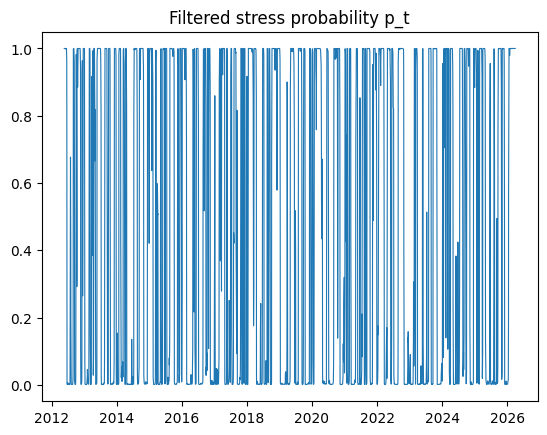

,p_stress
count,3485.000000
mean,0.472927
std,0.468341
min,0.001229
5%,0.001288
50%,0.259875
95%,1.000000
max,1.000000


In [10]:
# Quick diagnostics: distribution and persistence of p_t
fig, ax = plt.subplots()
ax.plot(p_stress.index, p_stress.values, linewidth=0.8)
ax.set_title("Filtered stress probability p_t")
plt.show()

display(p_stress.describe(percentiles=[0.05,0.5,0.95]))


<h3 style="font-weight:700;">6) Fit models</h3>
<ul>
<li><b>Global baseline:</b> PCA on the full training sample.</li>
<li><b>Piecewise baseline:</b> PCA by HMM-informed low/mid/high regimes.</li>
<li><b>Main challenger:</b> calm/stress covariance models blended with the lagged stress probability \(p_{t-1}\).</li>
</ul>


In [11]:
def fit_global_model(ret_train: pd.DataFrame, shrink, k: int) -> dict:
    mu, Sigma = estimate_mu_sigma(ret_train, shrink=shrink)
    pca = pca_on_correlation_arpm(Sigma.values)
    return dict(mu=mu, Sigma=Sigma, pca=pca, k=k)

def fit_regime_models(
    ret_train: pd.DataFrame,
    reg_train_for_ret: pd.Series,
    shrink,
    k: int,
    min_obs: int,
    fallback_global: dict,
) -> dict:
    models = {}
    if reg_train_for_ret is None:
        models["_fallback_global"] = fallback_global
        return models

    for reg in pd.Series(reg_train_for_ret.dropna().unique()).sort_values():
        idx = reg_train_for_ret[reg_train_for_ret == reg].index
        Xr = ret_train.reindex(idx).dropna()
        if len(Xr) < min_obs:
            continue
        mu, Sigma = estimate_mu_sigma(Xr, shrink=shrink)
        pca = pca_on_correlation_arpm(Sigma.values)
        models[str(reg)] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=len(Xr))
    models["_fallback_global"] = fallback_global
    return models


def fit_calm_stress_models(
    ret_train: pd.DataFrame,
    p_train_for_ret: pd.Series,
    shrink,
    k: int,
    min_obs_state: int,
    fallback_global: dict,
    estimation: str = "hard",
    eta_shrink_to_global: float = 0.0,
    shrink_mu_to_global: bool = False,
    p_threshold: float = 0.5,
) -> dict:
    """Estimate calm/stress models.

    estimation:
        - "hard": MAP assignment via p>=p_threshold
        - "weighted": soft assignment via weights (calm: 1-p, stress: p)
    eta_shrink_to_global:
        Sigma_state <- (1-eta)*Sigma_state + eta*Sigma_global (and optionally mu)
    """
    p = p_train_for_ret.astype(float)
    estimation = (estimation or "hard").lower().strip()

    models = {}
    mu_g = fallback_global["mu"]
    Sigma_g = fallback_global["Sigma"]

    if estimation in ("hard", "map", "hard_map"):
        state = pd.Series(index=p.index, dtype=object)
        state[p < p_threshold] = "calm"
        state[p >= p_threshold] = "stress"
        state[p.isna()] = np.nan

        for s in ["calm", "stress"]:
            idx = state[state == s].index
            Xs = ret_train.reindex(idx).dropna()
            if len(Xs) < min_obs_state:
                models[s] = fallback_global
            else:
                mu, Sigma = estimate_mu_sigma(Xs, shrink=shrink)
                mu, Sigma = shrink_params_to_global(mu, Sigma, mu_g, Sigma_g, eta=eta_shrink_to_global, shrink_mu=shrink_mu_to_global)
                pca = pca_on_correlation_arpm(Sigma.values)
                models[s] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=len(Xs))
        models["_state_counts"] = state.value_counts(dropna=False)

    elif estimation in ("weighted", "soft", "soft_assign"):
        w_stress = p.clip(0.0, 1.0)
        w_calm = (1.0 - w_stress).clip(0.0, 1.0)

        for s, w in [("calm", w_calm), ("stress", w_stress)]:
            ww = w.dropna()
            if len(ww) == 0 or float(ww.sum()) <= 0:
                models[s] = fallback_global
                continue
            eff_n = float(ww.sum()) ** 2 / float((ww ** 2).sum() + 1e-12)

            Xs = ret_train.reindex(w.index)
            if eff_n < min_obs_state:
                models[s] = fallback_global
            else:
                mu, Sigma = estimate_mu_sigma_weighted(Xs, w, shrink=shrink)
                mu, Sigma = shrink_params_to_global(mu, Sigma, mu_g, Sigma_g, eta=eta_shrink_to_global, shrink_mu=shrink_mu_to_global)
                pca = pca_on_correlation_arpm(Sigma.values)
                models[s] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=int(eff_n), eff_n=eff_n, sum_w=float(ww.sum()))
        models["_state_counts"] = pd.Series(
            {"calm_weight_sum": float(w_calm.sum()), "stress_weight_sum": float(w_stress.sum())}
        )
    else:
        raise ValueError(f"Unknown estimation='{estimation}'. Use 'hard' or 'weighted'.")

    models["_fallback_global"] = fallback_global
    models["_estimation"] = estimation
    models["_eta_shrink_to_global"] = float(eta_shrink_to_global or 0.0)
    models["_shrink_mu_to_global"] = bool(shrink_mu_to_global)
    return models

# --- fit
global_model = fit_global_model(ret_train, shrink=CONFIG["shrink"], k=CONFIG["k"])

# baseline piecewise PCA (optional)
reg_models = fit_regime_models(
    ret_train=ret_train,
    reg_train_for_ret=reg_train_for_ret,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs=CONFIG["min_obs_regime"],
    fallback_global=global_model
)

# HMM calm/stress models
cs_models_raw = fit_calm_stress_models(
    ret_train=ret_train,
    p_train_for_ret=p_train_for_ret,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs_state=CONFIG["min_obs_state"],
    fallback_global=global_model
)

print("Calm/Stress state counts (TRAIN, based on p_{t-1}>=0.5):")
display(cs_models_raw["_state_counts"])

# default alias (may be overwritten later if p-smoothing/model selection is enabled)
cs_models = cs_models_raw


# Convenience aliases (useful for sensitivity tests)
mu_calm   = cs_models["calm"]["mu"]
mu_stress = cs_models["stress"]["mu"]
Sigma_calm   = cs_models["calm"]["Sigma"].values
Sigma_stress = cs_models["stress"]["Sigma"].values


Calm/Stress state counts (TRAIN, based on p_{t-1}>=0.5):


,count
calm,1291
stress,1129
NaN,1


<h3 style="font-weight:700;">7) Static out-of-sample evaluation</h3>
Primary metric: Gaussian NLL (lower is better). PCA reconstruction <code>R^2</code> is reported only as a secondary descriptive metric.

Read this block together with the rolling section later on:
- the table below ranks the models by <b>realized static OOS performance</b>;
- the <b>validation-selected live candidate</b> is reported separately and may differ from the ex-post static winner.

In [12]:
import numpy as np
import pandas as pd

def _get_pca_eig(model: dict):
    """
    Extract eigenvectors/eigenvalues from `model["pca"]`.
    Expected: `model["pca"]["eigvecs"]` has shape (N,N) and `model["pca"]["eigvals"]` has shape (N,)
    """
    p = model["pca"]
    V = np.asarray(p["eigvecs"])
    lam = np.asarray(p["eigvals"]).reshape(-1)
    return V, lam

def pca_reconstruct_from_model(X: pd.DataFrame, model: dict, k=None) -> pd.DataFrame:
    """
    Linear rank-k reconstruction of returns X using the PCA object already stored in the model.
    Note: this is an optional descriptive comparison and does not affect NLL.
    """
    cols = X.columns
    V, lam = _get_pca_eig(model)
    kk = int(k if k is not None else model.get("k", len(cols)))
    kk = max(1, min(kk, V.shape[1], len(cols)))

    # projection onto the subspace spanned by the first k eigenvectors
    Vk = V[:, :kk]                 # N x k
    Xv = X.values                  # T x N
    scores = Xv @ Vk               # T x k
    Xhat = scores @ Vk.T           # T x N
    return pd.DataFrame(Xhat, index=X.index, columns=cols)

def reconstruct_global(ret: pd.DataFrame, global_model: dict, k=None) -> pd.DataFrame:
    return pca_reconstruct_from_model(ret, global_model, k=k)

def reconstruct_piecewise(ret: pd.DataFrame, reg_for_ret: pd.Series, reg_models: dict,
                          k=None, fallback_key: str = "_fallback_global") -> pd.DataFrame:
    """
    Apply reconstruction using the regime-specific model for each date.
    `reg_for_ret` must be indexed like `ret` (same dates).
    """
    yhat = pd.DataFrame(index=ret.index, columns=ret.columns, dtype=float)
    fb = reg_models.get(fallback_key, None)

    for t in ret.index:
        reg = reg_for_ret.loc[t] if t in reg_for_ret.index else np.nan
        key = str(reg) if pd.notna(reg) else None
        m = reg_models.get(key, None)
        if m is None:
            m = fb
        if m is None:
            raise KeyError("Fallback model not found in `reg_models`. Expected key '_fallback_global'.")
        yhat.loc[t:t] = pca_reconstruct_from_model(ret.loc[t:t], m, k=k).values

    return yhat

def r2_total(y: pd.DataFrame, yhat: pd.DataFrame) -> float:
    """
    Panel-wide R²: 1 - SSE/SST over the full stacked panel (all assets together).
    """
    yv = y.values
    yh = yhat.values
    sse = np.sum((yv - yh) ** 2)
    sst = np.sum((yv - np.mean(yv, axis=0, keepdims=True)) ** 2)
    return float(1.0 - sse / sst) if sst > 0 else np.nan

## 6.5) Smoothing on $p_t$ (stress probability) — optional but recommended

We can smooth the regime probability *before* using it as mixture weight / for calm–stress assignment.

Why: the filtered HMM probability can be noisy, which may induce unstable calm/stress splits and unstable mixture weights.

The smoother is selected only on a **validation slice inside TRAIN**. The notebook also reports the best realized static OOS model separately, but that diagnostic is **not** used for selection.


In [13]:
# ----------------------------
# 6.5) p_t smoothing / calibration (objective)
# ----------------------------

def smooth_p_series(p: pd.Series, method: str, param=None, pbar=None) -> pd.Series:
    """
    Smooth a probability series p_t in [0,1].

    Methods
    -------
    none:
        no change
    shrink_to_mean (alpha in [0,1]):
        p' = (1-alpha)*p + alpha*pbar    where pbar is computed on TRAIN (not on TEST)
    temperature (T>0):
        p' = sigmoid( logit(p) / T )
        - T>1 makes p less extreme (closer to 0.5), T<1 makes it sharper
    ema (gamma in [0,1)):
        p'_t = gamma*p'_{t-1} + (1-gamma)*p_t   (low-pass filter)
    """
    if p is None:
        return p
    p = p.astype(float).copy()
    eps = 1e-6
    p = p.clip(eps, 1 - eps)

    method = (method or "none").lower()

    if method in ("none", "raw"):
        return p

    if method in ("shrink_to_mean", "shrink", "shrink_to_train_mean"):
        if param is None:
            raise ValueError("shrink_to_mean needs param=alpha in [0,1].")
        if pbar is None or np.isnan(pbar):
            raise ValueError("shrink_to_mean needs pbar (TRAIN mean).")
        alpha = float(param)
        return (1 - alpha) * p + alpha * float(pbar)

    if method in ("temperature", "temp", "logit_temperature"):
        if param is None:
            raise ValueError("temperature needs param=T > 0.")
        T = float(param)
        if T <= 0:
            raise ValueError("T must be > 0.")
        x = np.log(p.values / (1 - p.values))
        x = x / T
        out = 1 / (1 + np.exp(-x))
        return pd.Series(out, index=p.index)

    if method in ("ema", "ewma", "exp_smooth"):
        if param is None:
            raise ValueError("ema needs param=gamma in [0,1).")
        gamma = float(param)
        if not (0 <= gamma < 1):
            raise ValueError("gamma must be in [0,1).")
        out = p.copy()
        first = out.first_valid_index()
        if first is None:
            return out
        y_prev = float(out.loc[first])
        start_pos = out.index.get_loc(first)
        for t in out.index[start_pos:]:
            x = float(out.loc[t])
            y = gamma * y_prev + (1 - gamma) * x
            out.loc[t] = y
            y_prev = y
        return out

    raise ValueError(f"Unknown smoothing method: {method}")


def mean_nll_mix_on_slice(
    ret_slice: pd.DataFrame,
    p_for_ret_slice: pd.Series,
    cs_models_slice: dict,
) -> float:
    Sigma_calm = cs_models_slice["calm"]["Sigma"].values
    Sigma_stress = cs_models_slice["stress"]["Sigma"].values
    mu_calm = cs_models_slice["calm"]["mu"].values
    mu_stress = cs_models_slice["stress"]["mu"].values
    return float(nll_hmm_mixture_given_p(ret_slice, p_for_ret_slice, Sigma_calm, Sigma_stress, mu_calm, mu_stress).mean())


# -------------------------------------------------------
# (A) Optional selection inside TRAIN (FIT + VAL)
# -------------------------------------------------------

P_SMOOTHER = {"method": "none", "param": None, "pbar_train": float(p_train_for_ret.dropna().mean())}

# We select (via VAL) to reduce discretion:
# - p-smoother (method + param)
# - calm/stress estimation method: hard vs weighted
# - eta shrink-to-global for calm/stress parameters
# - model family: "mixture" vs "volmix_corrfixed"
SELECTED = {
    "p_smoother": dict(P_SMOOTHER),
    "cs_estimation": "hard",
    "eta_shrink_to_global": 0.0,
    "model_family": "mixture",
    "shrink_mu_to_global": bool(CONFIG.get("shrink_mu_to_global", False)),
}

if CONFIG.get("do_model_selection", True) and (CONFIG.get("p_smoothing_method", "auto").lower() == "auto"):

    train_idx = ret_train.index
    train_end_dt = train_idx.max()
    val_years = int(CONFIG.get("val_years", 1))
    cut_dt = train_end_dt - pd.DateOffset(years=val_years)

    fit_idx = train_idx[train_idx <= cut_dt]
    val_idx = train_idx[train_idx > cut_dt]

    if len(val_idx) < 60 or len(fit_idx) < 252:
        print("WARN: validation split too small; falling back to defaults (no selection).")
    else:
        # 1) Refit HMM on FIT z only (no leakage), then compute p on FIT+VAL
        z_fit = z.reindex(fit_idx).dropna()
        hmm_params_sel = hmm_fit_gaussian_1d(
            z_fit,
            n_states=CONFIG["hmm_n_states"],
            max_iter=CONFIG["hmm_max_iter"],
            tol=CONFIG["hmm_tol"],
            var_floor=CONFIG["hmm_var_floor"],
            seed=CONFIG["hmm_seed"],
        )

        z_fitval = z.reindex(fit_idx.union(val_idx)).dropna()
        filt_sel = hmm_filter_probs(z_fitval, hmm_params_sel)
        p_sel = hmm_stress_probability(filt_sel, hmm_params_sel)

        p_fit_for_ret = p_sel.shift(1).reindex(fit_idx)
        p_val_for_ret = p_sel.shift(1).reindex(val_idx)

        # 2) Fit global on FIT only
        global_fit = fit_global_model(ret_train.reindex(fit_idx), shrink=CONFIG["shrink"], k=CONFIG["k"])
        fallback_fit = global_fit

        # baseline (global) on VAL
        nll_global_val = float(gaussian_nll_mean_global(ret_train.reindex(val_idx), global_fit))

        pbar_fit = float(p_fit_for_ret.dropna().mean())

        # Candidate grids
        candidates = [("none", None)]
        candidates += [("shrink_to_mean", a) for a in CONFIG.get("p_smoothing_alpha_grid", [0.0, 0.25, 0.5, 0.75, 0.9, 1.0])]
        candidates += [("temperature", T) for T in CONFIG.get("p_smoothing_T_grid", [0.75, 1.0, 1.25, 1.5, 2.0, 3.0])]
        candidates += [("ema", g) for g in CONFIG.get("p_smoothing_gamma_grid", [0.0, 0.25, 0.5, 0.75, 0.9])]

        eta_grid = CONFIG.get("eta_shrink_to_global_grid", [0.0, 0.25, 0.5, 0.75, 0.9])
        est_grid = CONFIG.get("cs_estimation_grid", ["hard", "weighted"])
        fam_grid = CONFIG.get("model_family_grid", ["mixture", "volmix_corrfixed"])

        rows = []
        for method, param in candidates:
            # Smooth FIT p (for calm/stress estimation)
            p_fit_s = smooth_p_series(p_fit_for_ret, method, param, pbar=pbar_fit)
            # Smooth VAL p (for mixture weights)
            p_val_s = smooth_p_series(p_val_for_ret, method, param, pbar=pbar_fit)

            for est in est_grid:
                for eta in eta_grid:
                    cs_fit = fit_calm_stress_models(
                        ret_train=ret_train.reindex(fit_idx),
                        p_train_for_ret=p_fit_s,
                        shrink=CONFIG["shrink"],
                        k=CONFIG["k"],
                        min_obs_state=CONFIG["min_obs_state"],
                        fallback_global=fallback_fit,
                        estimation=est,
                        eta_shrink_to_global=float(eta),
                        shrink_mu_to_global=bool(CONFIG.get("shrink_mu_to_global", False)),
                    )

                    for fam in fam_grid:
                        if fam == "mixture":
                            nll_val = float(gaussian_nll_mean_mixture(
                                ret_train.reindex(val_idx),
                                p_val_s,
                                cs_fit["calm"],
                                cs_fit["stress"],
                                fallback_model=fallback_fit,
                                ridge_mult=CONFIG["ridge_mult"],
                            ))
                        elif fam == "volmix_corrfixed":
                            nll_val = float(gaussian_nll_mean_volmix_corrfixed(
                                ret_train.reindex(val_idx),
                                p_val_s,
                                cs_fit["calm"],
                                cs_fit["stress"],
                                fallback_model=fallback_fit,
                                ridge_mult=CONFIG["ridge_mult"],
                            ))
                        else:
                            raise ValueError(f"Unknown model family: {fam}")

                        rows.append((
                            fam, est, float(eta), method, (None if param is None else float(param)),
                            nll_val, float(nll_val - nll_global_val)
                        ))

        sel = pd.DataFrame(
            rows,
            columns=["model_family","cs_estimation","eta_shrink_to_global","p_method","p_param","mean_nll_val","delta_vs_global_val"],
        ).sort_values("mean_nll_val")

        display(sel.head(20))

        best = sel.iloc[0]
        SELECTED = {
            "p_smoother": {"method": str(best["p_method"]), "param": (None if pd.isna(best["p_param"]) else float(best["p_param"])), "pbar_train": pbar_fit},
            "cs_estimation": str(best["cs_estimation"]),
            "eta_shrink_to_global": float(best["eta_shrink_to_global"]),
            "model_family": str(best["model_family"]),
            "shrink_mu_to_global": bool(CONFIG.get("shrink_mu_to_global", False)),
        }
        P_SMOOTHER = dict(SELECTED["p_smoother"])
        print("Validation-selected configuration:", SELECTED)

else:
    # manual choice (no tuning)
    m = CONFIG.get("p_smoothing_method", "none")
    P_SMOOTHER = {"method": m, "param": None, "pbar_train": float(p_train_for_ret.dropna().mean())}
    SELECTED["p_smoother"] = dict(P_SMOOTHER)
    SELECTED["cs_estimation"] = str(CONFIG.get("cs_estimation_grid", ["hard"])[0])
    SELECTED["eta_shrink_to_global"] = float(CONFIG.get("eta_shrink_to_global_grid", [0.0])[0])
    SELECTED["model_family"] = str(CONFIG.get("model_family_grid", ["mixture"])[0])
    print("Using selection (manual):", SELECTED)

# -------------------------------------------------------
# (B) Refit calm/stress models on FULL TRAIN using the chosen smoother + eta + estimation
# -------------------------------------------------------
pbar_train_full = float(p_train_for_ret.dropna().mean())
P_SMOOTHER["pbar_train"] = pbar_train_full
SELECTED["p_smoother"]["pbar_train"] = pbar_train_full

p_train_for_ret_used = smooth_p_series(p_train_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_train_full)
p_test_for_ret_used  = smooth_p_series(p_test_for_ret,  P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_train_full)

cs_models = fit_calm_stress_models(
    ret_train=ret_train,
    p_train_for_ret=p_train_for_ret_used,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs_state=CONFIG["min_obs_state"],
    fallback_global=global_model,
    estimation=SELECTED["cs_estimation"],
    eta_shrink_to_global=SELECTED["eta_shrink_to_global"],
    shrink_mu_to_global=SELECTED.get("shrink_mu_to_global", False),
)

print("Calm/Stress state counts (TRAIN) — after smoothing + selection:")
display(cs_models["_state_counts"])
print("Selected model family:", SELECTED["model_family"])


,model_family,cs_estimation,eta_shrink_to_global,p_method,p_param,mean_nll_val,delta_vs_global_val
101,volmix_corrfixed,hard,0.00,shrink_to_mean,0.90,-188.687551,-0.078941
103,volmix_corrfixed,hard,0.25,shrink_to_mean,0.90,-188.672090,-0.063480
70,mixture,weighted,0.00,shrink_to_mean,0.50,-188.659656,-0.051046
83,volmix_corrfixed,hard,0.25,shrink_to_mean,0.75,-188.659528,-0.050919
73,volmix_corrfixed,weighted,0.25,shrink_to_mean,0.50,-188.658464,-0.049855
85,volmix_corrfixed,hard,0.50,shrink_to_mean,0.75,-188.655318,-0.046708
105,volmix_corrfixed,hard,0.50,shrink_to_mean,0.90,-188.653630,-0.045020
75,volmix_corrfixed,weighted,0.50,shrink_to_mean,0.50,-188.652882,-0.044273
72,mixture,weighted,0.25,shrink_to_mean,0.50,-188.649815,-0.041206
71,volmix_corrfixed,weighted,0.00,shrink_to_mean,0.50,-188.649449,-0.040839


Validation-selected configuration: {'p_smoother': {'method': 'shrink_to_mean', 'param': 0.9, 'pbar_train': 0.457078296794146}, 'cs_estimation': 'hard', 'eta_shrink_to_global': 0.0, 'model_family': 'volmix_corrfixed', 'shrink_mu_to_global': False}
Calm/Stress state counts (TRAIN) — after smoothing + selection:


,count
calm,1396
stress,1024
NaN,1


Selected model family: volmix_corrfixed


In [14]:
# --- PCA reconstruction (optional comparison)
yhat_g = reconstruct_global(ret_test, global_model)

if CONFIG["do_piecewise_pca"]:
    yhat_pw = reconstruct_piecewise(ret_test, reg_test_for_ret, reg_models)
else:
    yhat_pw = None

print("Global PCA R2_total (test):", r2_total(ret_test, yhat_g))

if yhat_pw is not None:
    print("Piecewise PCA R2_total (test):", r2_total(ret_test, yhat_pw))


Global PCA R2_total (test): 0.4690816900037016
Piecewise PCA R2_total (test): 0.4660509702417256


In [15]:

# --- Main NLL comparisons (static OOS)
nll_global = gaussian_nll_mean_global(ret_test, global_model, ridge_mult=CONFIG["ridge_mult"])

if CONFIG["do_piecewise_pca"]:
    nll_piecewise = gaussian_nll_mean_piecewise(
        ret_test.reset_index(drop=True),
        reg_test_for_ret.reset_index(drop=True),
        reg_models,
        fallback_model=global_model,
        ridge_mult=CONFIG["ridge_mult"],
    )
else:
    nll_piecewise = np.nan

nll_hmm_mix = gaussian_nll_mean_mixture(
    ret_test.reset_index(drop=True),
    p_test_for_ret_used.reset_index(drop=True),
    cs_models["calm"],
    cs_models["stress"],
    fallback_model=global_model,
    ridge_mult=CONFIG["ridge_mult"],
)

if CONFIG.get("do_volmix_corrfixed", True):
    nll_volmix = gaussian_nll_mean_volmix_corrfixed(
        ret_test.reset_index(drop=True),
        p_test_for_ret_used.reset_index(drop=True),
        cs_models["calm"],
        cs_models["stress"],
        fallback_model=global_model,
        ridge_mult=CONFIG["ridge_mult"],
    )
else:
    nll_volmix = np.nan

validation_selected_label = (
    "HMM Mixture (validation-selected)"
    if SELECTED.get("model_family", "mixture") == "mixture"
    else "Vol-mix Corr-fixed (validation-selected)"
)

summary = pd.DataFrame(
    {
        "mean_nll": [nll_global, nll_piecewise, nll_hmm_mix, nll_volmix],
        "delta_vs_global": [0.0, nll_piecewise - nll_global, nll_hmm_mix - nll_global, nll_volmix - nll_global],
        "selected_in_train_validation": [
            False,
            False,
            validation_selected_label.startswith("HMM"),
            validation_selected_label.startswith("Vol-mix"),
        ],
    },
    index=[
        "Global (static)",
        "Piecewise PCA (HMM-informed thresholds)",
        "HMM Mixture (calm/stress)",
        "Vol-mix Corr-fixed (calm/stress)",
    ],
)

summary = summary.sort_values("mean_nll")
display(summary)

static_oos_winner = summary.index[0]
print("Validation-selected family:", validation_selected_label)
print("Best realized static OOS model (diagnostic only):", static_oos_winner)

if np.isfinite(nll_piecewise):
    print("Δ Mean NLL piecewise - global:", float(nll_piecewise - nll_global))
print("Δ Mean NLL HMM-mixture - global:", float(nll_hmm_mix - nll_global))
print("Δ Mean NLL Vol-mix (corr-fixed) - global:", float(nll_volmix - nll_global))


,mean_nll,delta_vs_global,selected_in_train_validation
HMM Mixture (calm/stress),-175.977520,-0.370490,False
Vol-mix Corr-fixed (calm/stress),-175.654821,-0.047791,True
Global (static),-175.607030,0.000000,False
Piecewise PCA (HMM-informed thresholds),-175.040682,0.566348,False


Validation-selected family: Vol-mix Corr-fixed (validation-selected)
Best realized static OOS model (diagnostic only): HMM Mixture (calm/stress)
Δ Mean NLL piecewise - global: 0.5663484880993224
Δ Mean NLL HMM-mixture - global: -0.3704899486392321
Δ Mean NLL Vol-mix (corr-fixed) - global: -0.047790582772478274


**Current V2 run — how to read the static table**

- **Validation-selected live candidate:** Vol-mix Corr-fixed  
- **Best realized static OOS model (diagnostic only):** HMM Mixture  
- **Global static mean NLL:** -175.607  
- **HMM mixture mean NLL:** -175.978 (**Δ vs global = -0.370**)  
- **Vol-mix Corr-fixed mean NLL:** -175.655 (**Δ vs global = -0.048**)  
- **Piecewise PCA mean NLL:** -175.041 (**Δ vs global = +0.566**)

So, in the current broad-US V2 run, the HMM mixture is the strongest **static** challenger, while the train/validation-selected live candidate remains Vol-mix Corr-fixed.

In [16]:
# --- NLL parts diagnostic (logdet vs quad)
# NOTE: here we use a *constant* pbar (average p on test) to build (mu_bar, Sigma_bar).
# This is ONLY a diagnostic decomposition (logdet vs quad). It is NOT the same as the dynamic HMM-mixture NLL,
# which uses time-varying p_t day-by-day. They coincide only if p_t is constant.
# For interpretability: compute average Sigma under mixture by using average p on test.
pbar = float(np.nanmean(p_test_for_ret_used.values))
Sigma_bar = (1-pbar)*cs_models["calm"]["Sigma"].values + pbar*cs_models["stress"]["Sigma"].values
mu_bar = (1-pbar)*cs_models["calm"]["mu"].values + pbar*cs_models["stress"]["mu"].values

ld_g, q_g = nll_parts(ret_test.astype(float), global_model["mu"].values, global_model["Sigma"].values, ridge_mult=CONFIG["ridge_mult"])
ld_m, q_m = nll_parts(ret_test.astype(float), mu_bar, Sigma_bar, ridge_mult=CONFIG["ridge_mult"])

pd.DataFrame(
    {
        "mean_logdet": [ld_g, ld_m],
        "mean_quad":   [q_g, q_m],
        "mean_nll":    [ld_g+q_g, ld_m+q_m],
    },
    index=["Global (static)", "HMM mixture (using avg p)"]
)


,mean_logdet,mean_quad,mean_nll
Global (static),-213.802220,38.19519,-175.607030
HMM mixture (using avg p),-213.158727,37.22328,-175.935447


## 6. Sensitivity: smoothing the regime signal $p_t$

If the **dynamic** mixture underperforms, it may be because $p_t$ is too noisy or too extreme.
Here we test two simple regularizations:

1. **Shrink to mean:** $p^{(\alpha)}_t = (1-\alpha)p_t + \alpha\bar p$
2. **Temperature scaling:** $p^{(T)}_t = \sigma(\operatorname{logit}(p_t)/T)$
3. **EMA smoothing:** a low-pass filter on the probability path

This block is a diagnostic sensitivity analysis on the **test set**. It is **not** a model-selection step.


In [17]:
# Sensitivity checks on TEST — how a noisy p_t helps or hurts.
# NOTE: this is a test-set diagnostic. Do NOT use it for model selection.

def nll_mix_test(p_for_ret: pd.Series) -> float:
    """Mean Gaussian NLL for HMM-mixture on TEST given an external p_t series."""
    p_al = p_for_ret.reindex(ret_test.index)
    return float(
        gaussian_nll_mean_mixture(
            ret_test,
            p_al,
            model_calm=cs_models["calm"],
            model_stress=cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=CONFIG.get("ridge_mult", 1e-3),
        )
    )

# baseline global (static)
nll_global_test = float(
    gaussian_nll_mean_global(
        ret_test,
        model=global_model,
        ridge_mult=CONFIG.get("ridge_mult", 1e-3),
    )
)

print("Validation-selected p-smoother:", P_SMOOTHER)
print("Global mean NLL (TEST):", nll_global_test)

pbar_train = float(p_train_for_ret.dropna().mean())

# --- shrink-to-mean grid (to TRAIN mean)
rows = []
for a in CONFIG.get("p_smoothing_alpha_grid", [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]):
    p_sh = smooth_p_series(p_test_for_ret, "shrink_to_mean", float(a), pbar=pbar_train)
    nll = nll_mix_test(p_sh)
    rows.append((a, nll, nll - nll_global_test))
alpha_tbl = pd.DataFrame(rows, columns=["alpha", "mean_nll", "delta_vs_global"]).sort_values("mean_nll")
display(alpha_tbl)

# --- temperature scaling grid
rows = []
for T in CONFIG.get("p_smoothing_T_grid", [0.75, 1.0, 1.25, 1.5, 2.0, 3.0]):
    pT = smooth_p_series(p_test_for_ret, "temperature", float(T), pbar=pbar_train)
    nll = nll_mix_test(pT)
    rows.append((T, nll, nll - nll_global_test))
T_tbl = pd.DataFrame(rows, columns=["T", "mean_nll", "delta_vs_global"]).sort_values("mean_nll")
display(T_tbl)

# --- EMA smoothing grid
rows = []
for g in CONFIG.get("p_smoothing_gamma_grid", [0.0, 0.25, 0.5, 0.75, 0.9]):
    pE = smooth_p_series(p_test_for_ret, "ema", float(g), pbar=pbar_train)
    nll = nll_mix_test(pE)
    rows.append((g, nll, nll - nll_global_test))
G_tbl = pd.DataFrame(rows, columns=["gamma", "mean_nll", "delta_vs_global"]).sort_values("mean_nll")
display(G_tbl)

Validation-selected p-smoother: {'method': 'shrink_to_mean', 'param': 0.9, 'pbar_train': 0.4663134489577213}
Global mean NLL (TEST): -175.60703001170634


,alpha,mean_nll,delta_vs_global
3,0.75,-176.014658,-0.407628
4,0.90,-175.977520,-0.370490
2,0.50,-175.974784,-0.367754
5,1.00,-175.927202,-0.320172
1,0.25,-175.793937,-0.186907
0,0.00,-175.417224,0.189806


,T,mean_nll,delta_vs_global
5,3.00,-175.997943,-0.390913
4,2.00,-175.739179,-0.132149
3,1.50,-175.576007,0.031023
2,1.25,-175.494658,0.112372
1,1.00,-175.417224,0.189806
0,0.75,-175.342867,0.264163


,gamma,mean_nll,delta_vs_global
4,0.90,-175.848026,-0.240996
3,0.75,-175.652193,-0.045163
2,0.50,-175.516870,0.090160
1,0.25,-175.460998,0.146032
0,0.00,-175.417224,0.189806


<h3 style="font-weight:700;">8) Visual diagnostics</h3>
Plots for the state variable, the filtered stress probability, their relationship, and regime counts.


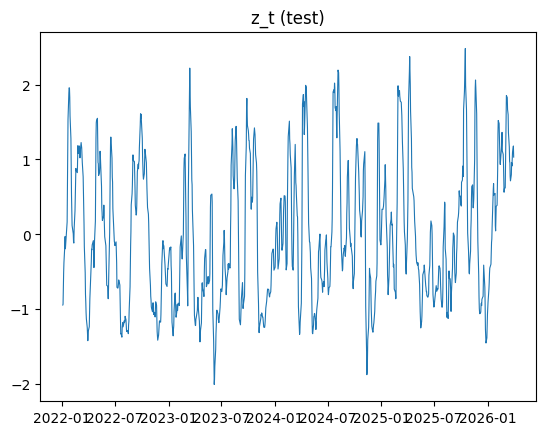

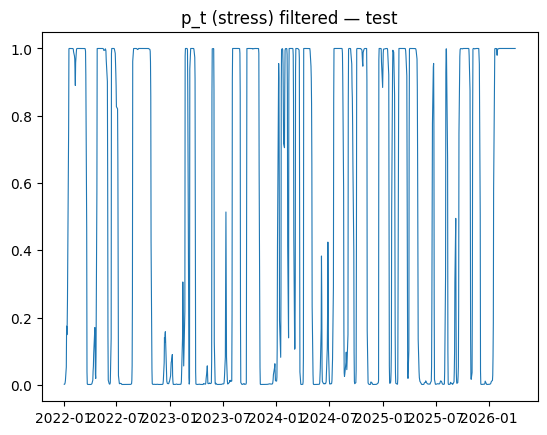

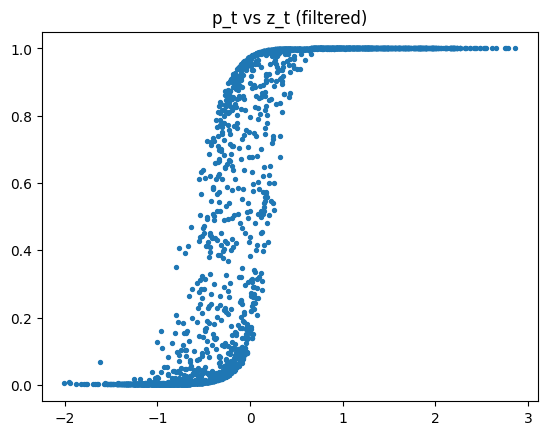

,count
calm,552
stress,512


In [18]:
# z and p on test
fig, ax = plt.subplots()
ax.plot(z.reindex(ret_test.index).index, z.reindex(ret_test.index).values, linewidth=0.8)
ax.set_title("z_t (test)")
plt.show()

fig, ax = plt.subplots()
ax.plot(p_stress.reindex(ret_test.index).index, p_stress.reindex(ret_test.index).values, linewidth=0.8)
ax.set_title("p_t (stress) filtered — test")
plt.show()

# scatter p vs z
tmp = pd.DataFrame({"z": z_eval, "p": p_stress.reindex(z_eval.index)}).dropna()
fig, ax = plt.subplots()
ax.scatter(tmp["z"], tmp["p"], s=8)
ax.set_title("p_t vs z_t (filtered)")
plt.show()

# state counts in test (MAP from p_{t-1})
p = p_test_for_ret.astype(float)
state_test = pd.Series(index=p.index, dtype=object)
state_test[p < 0.5] = "calm"
state_test[p >= 0.5] = "stress"
state_test[p.isna()] = np.nan
display(state_test.value_counts(dropna=False))


<h3 style="font-weight:700;">9) Block bootstrap — distribution of ΔNLL</h3>
Use moving-block bootstrap on the test set to estimate the distribution of:
- ΔmeanNLL (HMM-mixture − global)
- ΔmeanNLL (vol-mix − global)
- ΔmeanNLL (piecewise − global)

This section measures robustness of the static OOS comparison; it is not a model-selection step.

,delta_mean_NLL_mix_minus_global,delta_mean_NLL_volmix_minus_global,delta_mean_NLL_piecewise_minus_global
count,300.000000,300.000000,300.000000
mean,-0.362783,-0.040043,0.597457
std,0.072724,0.086154,0.357159
min,-0.576685,-0.328791,-0.541587
5%,-0.483259,-0.172571,0.035090
50%,-0.354537,-0.040987,0.591261
95%,-0.255362,0.093574,1.149337
max,-0.171495,0.228064,1.663883


P( HMM-mixture beats global ) = 1.0
P( Vol-mix Corr-fixed beats global ) = 0.6733333333333333
P( piecewise beats global ) = 0.05


,p_win (Δ<0),p_lose (Δ>0),avg_win |Δ| (if win),avg_loss Δ (if lose),EV improvement = E[-Δ],Omega (sum gains / sum losses)
HMM-mixture vs global,1.0,0.0,0.362783,NaN,0.362783,NaN


,p_win (Δ<0),p_lose (Δ>0),avg_win |Δ| (if win),avg_loss Δ (if lose),EV improvement = E[-Δ],Omega (sum gains / sum losses)
Vol-mix Corr-fixed vs global,0.673333,0.326667,0.085587,0.053832,0.040043,3.277127


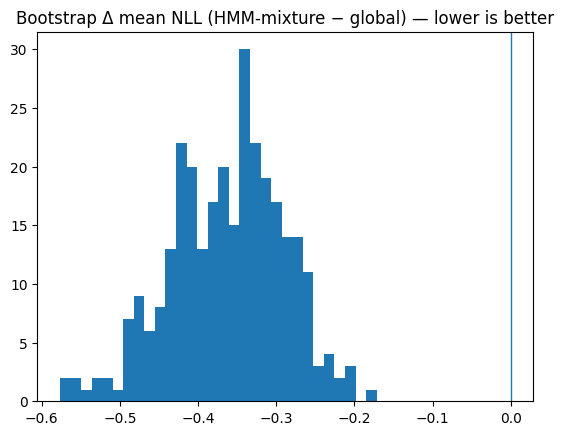

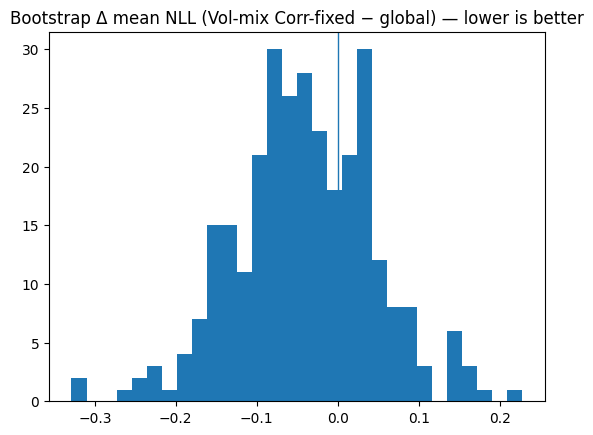

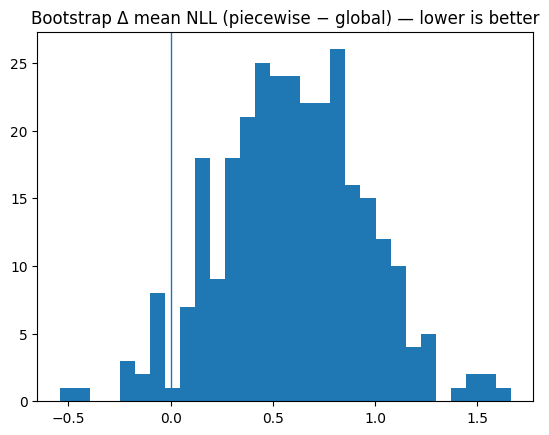

In [19]:
# ----------------------------
# 9) Bootstrap: compare mean NLL deltas (mixture / vol-mix / piecewise) vs global
# ----------------------------
def moving_block_bootstrap_indices(n: int, block: int, rng: np.random.Generator) -> np.ndarray:
    if block < 1:
        raise ValueError("block must be >= 1")
    block = min(block, n)
    m = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=m)
    idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
    return idx

def bootstrap_deltas_nll(
    ret_test: pd.DataFrame,
    p_test_for_ret: pd.Series,
    global_model: dict,
    cs_models: dict,
    reg_test_for_ret=None,
    reg_models=None,
    B: int = 300,
    block: int = 20,
    seed: int = 7,
    ridge_mult: float = 1e-3,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(ret_test)
    out = []

    for _ in range(B):
        idx = moving_block_bootstrap_indices(n, block, rng)

        y = ret_test.iloc[idx].reset_index(drop=True)
        p = p_test_for_ret.iloc[idx].reset_index(drop=True)

        nll_g = gaussian_nll_mean_global(y, global_model, ridge_mult=ridge_mult)

        nll_mix = gaussian_nll_mean_mixture(
            y, p,
            cs_models["calm"], cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=ridge_mult
        )

        nll_volmix = gaussian_nll_mean_volmix_corrfixed(
            y, p,
            cs_models["calm"], cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=ridge_mult
        )

        row = {
            "delta_mean_NLL_mix_minus_global": float(nll_mix - nll_g),
            "delta_mean_NLL_volmix_minus_global": float(nll_volmix - nll_g),
        }

        if (reg_test_for_ret is not None) and (reg_models is not None) and CONFIG["do_piecewise_pca"]:
            reg = reg_test_for_ret.iloc[idx].reset_index(drop=True)
            nll_pw = gaussian_nll_mean_piecewise(
                y, reg,
                reg_models=reg_models,
                fallback_model=global_model,
                ridge_mult=ridge_mult
            )
            row["delta_mean_NLL_piecewise_minus_global"] = float(nll_pw - nll_g)

        out.append(row)

    return pd.DataFrame(out)

def win_loss_table(delta: pd.Series, name: str) -> pd.DataFrame:
    d = delta.astype(float)
    p_win  = float((d < 0).mean())
    p_lose = float((d > 0).mean())
    win_mag  = (-d[d < 0])  # positive improvements
    loss_mag = ( d[d > 0])  # positive deteriorations

    avg_win  = float(win_mag.mean())  if len(win_mag)  else np.nan
    avg_loss = float(loss_mag.mean()) if len(loss_mag) else np.nan

    ev_impr = float((-d).mean())  # E[-Δ], positive means improvement on avg
    omega = float(win_mag.sum() / loss_mag.sum()) if (len(win_mag) and len(loss_mag) and loss_mag.sum() > 0) else np.nan

    return pd.DataFrame({
        "p_win (Δ<0)": [p_win],
        "p_lose (Δ>0)": [p_lose],
        "avg_win |Δ| (if win)": [avg_win],
        "avg_loss Δ (if lose)": [avg_loss],
        "EV improvement = E[-Δ]": [ev_impr],
        "Omega (sum gains / sum losses)": [omega],
    }, index=[name])

if CONFIG["do_bootstrap"]:
    boot = bootstrap_deltas_nll(
        ret_test=ret_test,
        p_test_for_ret=p_test_for_ret_used,
        global_model=global_model,
        cs_models=cs_models,
        reg_test_for_ret=reg_test_for_ret if CONFIG["do_piecewise_pca"] else None,
        reg_models=reg_models if CONFIG["do_piecewise_pca"] else None,
        B=CONFIG["bootstrap_B"],
        block=CONFIG["bootstrap_block"],
        seed=CONFIG.get("bootstrap_seed", 7),
        ridge_mult=CONFIG["ridge_mult"],
    )

    display(boot.describe(percentiles=[0.05, 0.5, 0.95]))

    print("P( HMM-mixture beats global ) =", float((boot["delta_mean_NLL_mix_minus_global"] < 0).mean()))
    print("P( Vol-mix Corr-fixed beats global ) =", float((boot["delta_mean_NLL_volmix_minus_global"] < 0).mean()))
    if "delta_mean_NLL_piecewise_minus_global" in boot.columns:
        print("P( piecewise beats global ) =", float((boot["delta_mean_NLL_piecewise_minus_global"] < 0).mean()))

    display(win_loss_table(boot["delta_mean_NLL_mix_minus_global"], "HMM-mixture vs global"))
    display(win_loss_table(boot["delta_mean_NLL_volmix_minus_global"], "Vol-mix Corr-fixed vs global"))

    fig, ax = plt.subplots()
    ax.hist(boot["delta_mean_NLL_mix_minus_global"], bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap Δ mean NLL (HMM-mixture − global) — lower is better")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot["delta_mean_NLL_volmix_minus_global"], bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap Δ mean NLL (Vol-mix Corr-fixed − global) — lower is better")
    plt.show()

    if "delta_mean_NLL_piecewise_minus_global" in boot.columns:
        fig, ax = plt.subplots()
        ax.hist(boot["delta_mean_NLL_piecewise_minus_global"], bins=30)
        ax.axvline(0, linewidth=1)
        ax.set_title("Bootstrap Δ mean NLL (piecewise − global) — lower is better")
        plt.show()


## 10) Rolling recalibration (walk-forward)

Goal: emulate a live workflow where the model is periodically refit using only past data.

At each refit date:
1. Fit the **global** model on a trailing return window.
2. Fit the **HMM** on the trailing window of the state variable $z_t$.
3. Estimate calm/stress return models using lagged probabilities.
4. Score the next period until the following refit with filtered probabilities only.

This section is the cleanest proxy for live deployment. In the current executed run, the rolling global benchmark remains slightly better than the regime-aware challengers, so the static and rolling results should be interpreted separately.

,Mean NLL
Global static,-175.607030
HMM-mixture static,-175.417224
Vol-mix Corr-fixed static,-173.812206
Global rolling,-179.421575
HMM-mixture rolling,-179.397986
Vol-mix Corr-fixed rolling,-179.329032


Δ Mean NLL (rolling mix - rolling global): 0.023589219869764397
Δ Mean NLL (rolling vol-mix - rolling global): 0.09254344677878551


,boot_mean_delta_mix_minus_global,boot_mean_delta_volmix_minus_global
count,300.000000,300.000000
mean,0.027323,0.087553
std,0.026742,0.055427
min,-0.048912,-0.050464
5%,-0.014705,0.001220
50%,0.026272,0.086052
95%,0.075983,0.185250
max,0.098243,0.233040


P( rolling mixture beats rolling global ) = 0.13333333333333333
P( rolling vol-mix beats rolling global ) = 0.05


,p_win (Δ<0),p_lose (Δ>0),avg_win |Δ| (if win),avg_loss Δ (if lose),EV improvement = E[-Δ],Omega (sum gains / sum losses)
rolling mix vs rolling global,0.133333,0.866667,0.014259,0.03372,-0.027323,0.065057
rolling vol-mix vs rolling global,0.050000,0.950000,0.019162,0.09317,-0.087553,0.010825


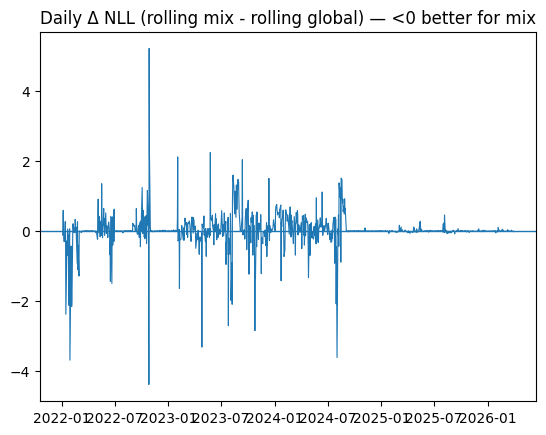

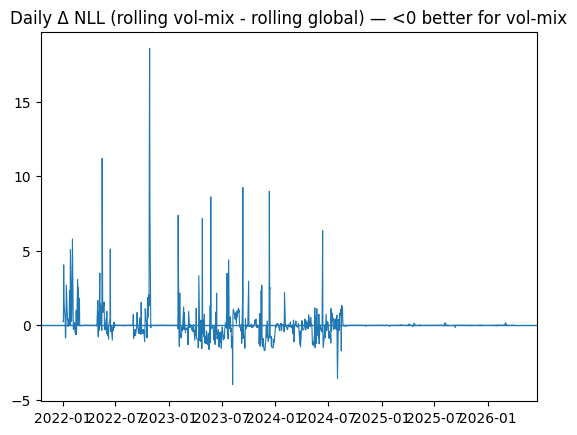

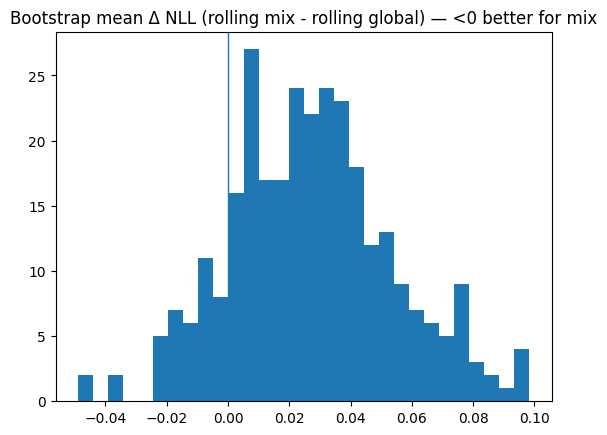

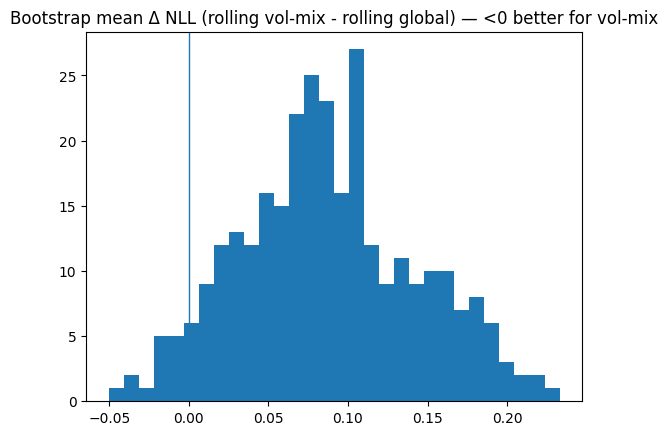

In [20]:
# ----------------------------
# 10) Rolling recalibration (walk-forward template)
# ----------------------------
def gaussian_nll_series_global(rets: pd.DataFrame, model: dict, ridge_mult: float = 1e-3) -> pd.Series:
    R = rets.astype(float)
    cols = R.columns

    mu = model["mu"].reindex(cols).astype(float).values
    Sigma = model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2*np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    out = np.empty(len(R), dtype=float)
    for i in range(len(R)):
        x = R.values[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=R.index, name="nll_global")

def gaussian_nll_series_mixture(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> pd.Series:
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values
    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    out = np.empty(len(Rdf), dtype=float)
    for i in range(len(Rdf)):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            Sigma = (1.0 - pi) * Sc + pi * Ss

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2*np.eye(S.shape[0])
            sign, logdet = np.linalg.slogdet(S)

        x = R[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=Rdf.index, name="nll_mix")

def gaussian_nll_series_volmix_corrfixed(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> pd.Series:
    """Series NLL where ONLY vol levels are mixed by p_t; correlation fixed from fallback_model."""
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Corr = _cov_to_corr(Sg)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values

    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    sig_c = np.sqrt(np.clip(np.diag(Sc), 1e-18, np.inf))
    sig_s = np.sqrt(np.clip(np.diag(Ss), 1e-18, np.inf))

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values

    out = np.empty(len(Rdf), dtype=float)
    for i in range(len(Rdf)):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            sig = (1.0 - pi) * sig_c + pi * sig_s
            Sigma = np.outer(sig, sig) * Corr

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2*np.eye(S.shape[0])
            sign, logdet = np.linalg.slogdet(S)

        x = R[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=Rdf.index, name="nll_volmix")

def first_trading_days(idx: pd.DatetimeIndex, freq: str = "MS") -> pd.DatetimeIndex:
    idx = pd.DatetimeIndex(idx).sort_values()
    if freq == "MS":
        key = idx.to_period("M")
    elif freq == "QS":
        key = idx.to_period("Q")
    elif freq in ("AS", "YS"):
        key = idx.to_period("A")
    else:
        raise ValueError("rolling_refit_freq must be 'MS' or 'QS' (or 'YS').")
    firsts = idx.to_series().groupby(key).min().sort_values().values
    return pd.DatetimeIndex(firsts)

def block_bootstrap_mean(delta: pd.Series, B: int = 300, block: int = 20, seed: int = 7) -> pd.Series:
    rng = np.random.default_rng(seed)
    delta = delta.dropna()
    n = len(delta)
    if n == 0:
        raise ValueError("delta is empty after dropna().")
    block = min(block, n)
    m = int(np.ceil(n / block))
    out = np.empty(B, dtype=float)
    vals = delta.values
    for b in range(B):
        starts = rng.integers(0, n - block + 1, size=m)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        out[b] = float(np.mean(vals[idx]))
    return pd.Series(out, name="boot_mean_delta")

def rolling_recalibration_backtest(
    ret_train: pd.DataFrame,
    ret_test: pd.DataFrame,
    z: pd.Series,
    shrink,
    k: int,
    min_obs_state: int,
    window_years: int = 5,
    refit_freq: str = "MS",
    min_obs: int = 500,
) -> pd.DataFrame:
    ret_all = pd.concat([ret_train, ret_test]).sort_index()
    test_idx = pd.DatetimeIndex(ret_test.index).sort_values()

    refits = first_trading_days(test_idx, freq=refit_freq)
    if refits[0] != test_idx.min():
        refits = pd.DatetimeIndex([test_idx.min()]).append(refits[refits > test_idx.min()])

    nll_roll_global = pd.Series(index=test_idx, dtype=float, name="nll_roll_global")
    nll_roll_mix    = pd.Series(index=test_idx, dtype=float, name="nll_roll_mix")
    nll_roll_volmix = pd.Series(index=test_idx, dtype=float, name="nll_roll_volmix")

    for j, d0 in enumerate(refits):
        d1 = refits[j+1] if (j+1) < len(refits) else (test_idx.max() + pd.Timedelta(days=1))
        chunk_idx = test_idx[(test_idx >= d0) & (test_idx < d1)]
        if len(chunk_idx) == 0:
            continue

        prev_dates = ret_all.index[ret_all.index < d0]
        if len(prev_dates) == 0:
            continue
        cal_end = prev_dates.max()

        win_start = cal_end - pd.DateOffset(years=window_years)
        ret_win = ret_all.loc[win_start:cal_end].dropna()
        if len(ret_win) < min_obs:
            continue

        z_win = z.reindex(ret_win.index).dropna()
        if len(z_win) < 20:
            continue

        global_win = fit_global_model(ret_win, shrink=shrink, k=k)

        hmm_params_win = hmm_fit_gaussian_1d(
            z_win,
            n_states=CONFIG["hmm_n_states"],
            max_iter=CONFIG.get("hmm_max_iter_rolling", CONFIG["hmm_max_iter"]),
            tol=CONFIG["hmm_tol"],
            var_floor=CONFIG["hmm_var_floor"],
            seed=CONFIG["hmm_seed"],
        )

        filt_win = hmm_filter_probs(z_win, hmm_params_win)
        p_win = hmm_stress_probability(filt_win, hmm_params_win)
        p_win_for_ret = p_win.shift(1).reindex(ret_win.index)
        pbar_win = float(p_win_for_ret.dropna().mean())
        p_win_for_ret = smooth_p_series(p_win_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_win)

        cs_win = fit_calm_stress_models(
            ret_train=ret_win,
            p_train_for_ret=p_win_for_ret,
            shrink=shrink,
            k=k,
            min_obs_state=min_obs_state,
            fallback_global=global_win,
            estimation=SELECTED.get('cs_estimation','hard'),
            eta_shrink_to_global=float(SELECTED.get('eta_shrink_to_global',0.0)),
            shrink_mu_to_global=bool(SELECTED.get('shrink_mu_to_global', False)),
        )

        # filter p over [cal_end] + chunk to get p_{t-1} for first day in chunk
        z_filter_idx = pd.DatetimeIndex([cal_end]).append(chunk_idx)
        z_filter = z.reindex(z_filter_idx).dropna()
        if len(z_filter) < 2:
            continue

        filt_chunk = hmm_filter_probs(z_filter, hmm_params_win)
        p_chunk = hmm_stress_probability(filt_chunk, hmm_params_win)
        p_chunk_for_ret = p_chunk.shift(1).reindex(chunk_idx)

        R_chunk = ret_all.reindex(chunk_idx).dropna()
        p_chunk_for_ret = p_chunk_for_ret.reindex(R_chunk.index)
        p_chunk_for_ret = smooth_p_series(p_chunk_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_win)
        if len(R_chunk) == 0:
            continue

        nll_roll_global.loc[R_chunk.index] = gaussian_nll_series_global(R_chunk, global_win, ridge_mult=CONFIG["ridge_mult"])
        nll_roll_mix.loc[R_chunk.index] = gaussian_nll_series_mixture(
            R_chunk,
            p_chunk_for_ret,
            cs_win["calm"],
            cs_win["stress"],
            fallback_model=global_win,
            ridge_mult=CONFIG["ridge_mult"],
        )
        nll_roll_volmix.loc[R_chunk.index] = gaussian_nll_series_volmix_corrfixed(
            R_chunk,
            p_chunk_for_ret,
            cs_win["calm"],
            cs_win["stress"],
            fallback_model=global_win,
            ridge_mult=CONFIG["ridge_mult"],
        )

    return pd.concat([nll_roll_global, nll_roll_mix, nll_roll_volmix], axis=1)

if CONFIG.get("do_rolling_recalibration", False):
    roll = rolling_recalibration_backtest(
        ret_train=ret_train,
        ret_test=ret_test,
        z=z,
        shrink=CONFIG["shrink"],
        k=CONFIG["k"],
        min_obs_state=CONFIG["min_obs_state"],
        window_years=CONFIG["rolling_window_years"],
        refit_freq=CONFIG["rolling_refit_freq"],
        min_obs=CONFIG["rolling_min_obs"],
    )

    # static series for reference
    nll_static_global_s = gaussian_nll_series_global(ret_test, global_model, ridge_mult=CONFIG["ridge_mult"])
    nll_static_mix_s    = gaussian_nll_series_mixture(ret_test, p_test_for_ret, cs_models["calm"], cs_models["stress"], global_model, ridge_mult=CONFIG["ridge_mult"])
    nll_static_vm_s     = gaussian_nll_series_volmix_corrfixed(ret_test, p_test_for_ret, cs_models["calm"], cs_models["stress"], global_model, ridge_mult=CONFIG["ridge_mult"])

    summary_roll = pd.DataFrame({
        "Mean NLL": [
            float(nll_static_global_s.mean()),
            float(nll_static_mix_s.mean()),
            float(nll_static_vm_s.mean()),
            float(roll["nll_roll_global"].mean()),
            float(roll["nll_roll_mix"].mean()),
            float(roll["nll_roll_volmix"].mean()),
        ],
    }, index=["Global static", "HMM-mixture static", "Vol-mix Corr-fixed static",
              "Global rolling", "HMM-mixture rolling", "Vol-mix Corr-fixed rolling"])
    display(summary_roll)

    # --- rolling deltas (fair comparisons)
    delta_roll_mix = (roll["nll_roll_mix"] - roll["nll_roll_global"]).dropna()
    delta_roll_vm  = (roll["nll_roll_volmix"] - roll["nll_roll_global"]).dropna()

    print("Δ Mean NLL (rolling mix - rolling global):", float(delta_roll_mix.mean()))
    print("Δ Mean NLL (rolling vol-mix - rolling global):", float(delta_roll_vm.mean()))

    # bootstrap on mean deltas (efficient)
    boot_mix = block_bootstrap_mean(delta_roll_mix, B=CONFIG["bootstrap_B"], block=CONFIG["bootstrap_block"], seed=CONFIG.get("bootstrap_seed", 7))
    boot_vm  = block_bootstrap_mean(delta_roll_vm,  B=CONFIG["bootstrap_B"], block=CONFIG["bootstrap_block"], seed=CONFIG.get("bootstrap_seed", 7))

    display(pd.DataFrame({
        "boot_mean_delta_mix_minus_global": boot_mix,
        "boot_mean_delta_volmix_minus_global": boot_vm,
    }).describe(percentiles=[0.05, 0.5, 0.95]))

    p_win_mix = float((boot_mix < 0).mean())
    p_win_vm  = float((boot_vm  < 0).mean())
    print("P( rolling mixture beats rolling global ) =", p_win_mix)
    print("P( rolling vol-mix beats rolling global ) =", p_win_vm)

    def wl(delta_boot: pd.Series) -> dict:
        wins = -delta_boot[delta_boot < 0]
        losses = delta_boot[delta_boot > 0]
        return {
            "p_win (Δ<0)": float((delta_boot < 0).mean()),
            "p_lose (Δ>0)": float((delta_boot > 0).mean()),
            "avg_win |Δ| (if win)": float(wins.mean()) if len(wins) else np.nan,
            "avg_loss Δ (if lose)": float(losses.mean()) if len(losses) else np.nan,
            "EV improvement = E[-Δ]": float((-delta_boot).mean()),
            "Omega (sum gains / sum losses)": float(wins.sum() / losses.sum()) if losses.sum() > 0 else np.inf,
        }

    display(pd.DataFrame([wl(boot_mix), wl(boot_vm)], index=["rolling mix vs rolling global", "rolling vol-mix vs rolling global"]))

    fig, ax = plt.subplots()
    ax.plot(delta_roll_mix.index, delta_roll_mix.values, linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title("Daily Δ NLL (rolling mix - rolling global) — <0 better for mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(delta_roll_vm.index, delta_roll_vm.values, linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title("Daily Δ NLL (rolling vol-mix - rolling global) — <0 better for vol-mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot_mix.values, bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap mean Δ NLL (rolling mix - rolling global) — <0 better for mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot_vm.values, bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap mean Δ NLL (rolling vol-mix - rolling global) — <0 better for vol-mix")
    plt.show()


**Bootstrap and rolling interpretation for the current V2 run**

- **Static block bootstrap:** HMM vs global has mean ΔNLL ≈ **-0.363** and **P(win) = 1.00**.  
- **Rolling recalibration:** the rolling global benchmark remains slightly better than both regime-aware challengers.  
- Therefore, the notebook currently supports a strong **static OOS** regime-aware result, but not yet a stronger **live / walk-forward** claim.

<h3 style="font-weight:700;">11) Final notes</h3>

<ul>
  <li><b>Main static finding:</b> within this low-rank regime-aware family, the HMM-mixture is the strongest static OOS challenger in the current run.</li>
  <li><b>Validation vs realized winner:</b> the live configuration is chosen on train/validation only; in this run the validation-selected live candidate is <b>Vol-mix Corr-fixed</b>, while the best realized static OOS model is <b>HMM Mixture</b>.</li>
  <li><b>Rolling evidence:</b> the rolling global benchmark remains slightly better, so the current notebook supports a strong <i>static</i> result more than a fully mature live-selection pipeline.</li>
  <li><b>Numerics:</b> NLL requires matrix inversion, so the notebook uses a ridge proportional to average variance for conditioning stability.</li>
  <li><b>Scope:</b> this is a research notebook on conditional covariance / density forecasting, not a production risk engine.</li>
</ul>